In [2]:
import subprocess
subprocess.run(['pip', 'install', 'libpysal', 'spopt'], check=True)

CompletedProcess(args=['pip', 'install', 'libpysal', 'spopt'], returncode=0)

In [3]:
import libpysal
import spopt
from spopt.region import Skater
print(f"libpysal version: {libpysal.__version__}")
print(f"spopt version: {spopt.__version__}")
print("All imports successful")

libpysal version: 4.14.1
spopt version: 0.7.0
All imports successful


Loading data...
Loaded 1916 panchayats
CSV columns:
['Name_1', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'TSI_score', 'TSI_class', 'TOD_cluster', 'cluster_id', 'cluster_kmeans', 'kmeans_label', 'cluster_dbscan', 'dbscan_label', 'cluster_skater', 'skater_label']
All indicators found

[1/3] Running K-means...
k=3: silhouette=0.3457
k=4: silhouette=0.3736
k=5: silhouette=0.3447
k=6: silhouette=0.3473
k=7: silhouette=0.3509

Best K = 4

[2/3] Running DBSCAN...
Clusters found: 2
Noise points: 43

[3/3] Running SKATER...
Disconnected islands: 0
k=3: silhouette=0.1662
k=4: silhouette=-0.0285
k=5: silhouette=-0.0874
k=6: silhouette=-0.2012

Creating maps...

Exporting...


MemoryError: Unable to allocate 7.00 GiB for an array with shape (939525116,) and data type int64

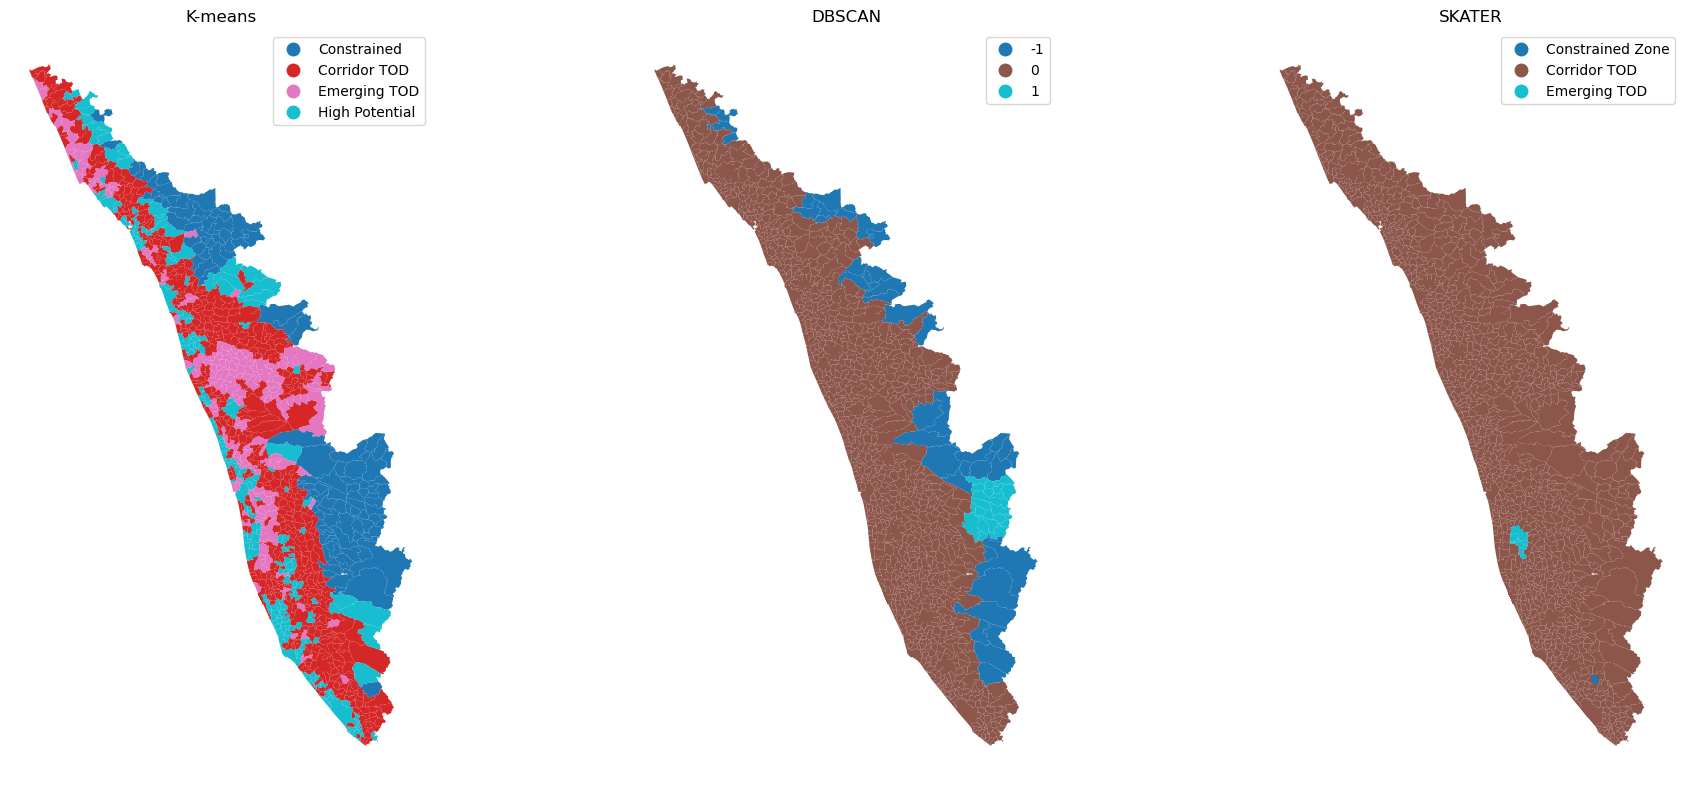

In [16]:
import geopandas as gpd
import pandas as pd
import numpy as np
import libpysal
from spopt.region import Skater
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import warnings
import os

warnings.filterwarnings("ignore")

# ============================================================
# FILE PATHS
# ============================================================

master_csv = r"D:\MPLAN\thesis\objective 2\kerala_TSI_all_clusters_afterremovingduplicates.csv"

# IMPORTANT: Give actual shapefile (.shp)
shape_file = r"D:\MPLAN\thesis\objective 2\Export_LSGD.shp"

output_folder = r"D:\MPLAN\thesis\objective 2"
os.makedirs(output_folder, exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

print("Loading data...")

master = pd.read_csv(master_csv)

gdf = gpd.read_file(shape_file)
gdf = gdf.to_crs("EPSG:32643")

# Merge
gdf = gdf.merge(master, on="Name_1", how="left")

# Required indicators
ind_cols = ['I1','I2','I3','I4','I5','I6']

# Fill missing values
for col in ind_cols:
    gdf[col] = gdf[col].fillna(0)

gdf['TSI_score'] = gdf['TSI_score'].fillna(0)

X = gdf[ind_cols].values

print(f"Loaded {len(gdf)} panchayats")


master = pd.read_csv(master_csv)

# Remove spaces from column names
master.columns = master.columns.str.strip()

print("CSV columns:")
print(master.columns.tolist())

# Required indicators
ind_cols = ['I1','I2','I3','I4','I5','I6']

# Check missing columns
missing_cols = [col for col in ind_cols if col not in master.columns]

if len(missing_cols) > 0:
    print("Missing columns:", missing_cols)
else:
    print("All indicators found")

# ============================================================
# METHOD 1 — KMEANS
# ============================================================

print("\n[1/3] Running K-means...")

sil_scores = {}

for k in range(3, 8):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = km.fit_predict(X)

    sil = silhouette_score(X, labels)

    sil_scores[k] = sil

    print(f"k={k}: silhouette={sil:.4f}")

best_k = max(sil_scores, key=sil_scores.get)

print(f"\nBest K = {best_k}")

km_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

gdf['cluster_kmeans'] = km_final.fit_predict(X)

# Name clusters
cluster_means = (
    gdf.groupby("cluster_kmeans")['TSI_score']
    .mean()
    .sort_values()
)

cluster_names = [
    'Constrained',
    'Emerging TOD',
    'Corridor TOD',
    'High Potential',
    'Primary TOD Hub'
][:best_k]

name_map = {}

for rank, cid in enumerate(cluster_means.index):
    name_map[cid] = cluster_names[rank]

gdf['kmeans_label'] = gdf['cluster_kmeans'].map(name_map)

# ============================================================
# METHOD 2 — DBSCAN
# ============================================================

print("\n[2/3] Running DBSCAN...")

# Panchayat centroids
centroids = gdf.geometry.centroid

coords = np.column_stack([
    centroids.x.values / 1000,
    centroids.y.values / 1000
])

# Add TSI weighting
tsi_scaled = (
    gdf['TSI_score'].values.reshape(-1,1)
    * 15
)

X_dbscan = np.hstack([
    coords,
    tsi_scaled
])

db = DBSCAN(
    eps=10,
    min_samples=5
)

gdf['cluster_dbscan'] = db.fit_predict(X_dbscan)

n_clusters_db = len(set(gdf['cluster_dbscan'])) - (
    1 if -1 in gdf['cluster_dbscan'].values else 0
)

noise_points = list(
    gdf['cluster_dbscan']
).count(-1)

print(f"Clusters found: {n_clusters_db}")
print(f"Noise points: {noise_points}")

# Name DBSCAN clusters
valid_db = gdf[gdf['cluster_dbscan'] >= 0]

if len(valid_db) > 0:

    db_means = (
        valid_db.groupby("cluster_dbscan")['TSI_score']
        .mean()
        .sort_values(ascending=False)
    )

    db_name_map = {}

    for i, cid in enumerate(db_means.index):
        db_name_map[cid] = f"Corridor {i+1}"

    db_name_map[-1] = "Noise"

    gdf['dbscan_label'] = (
        gdf['cluster_dbscan']
        .map(db_name_map)
    )

# ============================================================
# METHOD 3 — SKATER
# ============================================================

print("\n[3/3] Running SKATER...")

gdf_clean = gdf.copy().reset_index(drop=True)

# Spatial weights
w = libpysal.weights.Queen.from_dataframe(gdf_clean)

print(f"Disconnected islands: {len(w.islands)}")

# Remove islands if any
if len(w.islands) > 0:

    keep = [
        i for i in range(len(gdf_clean))
        if i not in w.islands
    ]

    gdf_skater = (
        gdf_clean.iloc[keep]
        .reset_index(drop=True)
    )

    w = libpysal.weights.Queen.from_dataframe(
        gdf_skater
    )

else:

    gdf_skater = gdf_clean.copy()

skater_results = {}

for k in range(3, 7):

    try:

        model = Skater(
            gdf_skater,
            w,
            attrs_name=ind_cols,
            n_clusters=k,
            floor=2
        )

        model.solve()

        labels = model.labels_

        sil = silhouette_score(
            gdf_skater[ind_cols].values,
            labels
        )

        skater_results[k] = {
            "model": model,
            "labels": labels,
            "silhouette": sil
        }

        print(f"k={k}: silhouette={sil:.4f}")

    except Exception as e:

        print(f"k={k} failed: {e}")

best_k_skater = max(
    skater_results,
    key=lambda x: skater_results[x]['silhouette']
)

best_skater = skater_results[best_k_skater]

gdf_skater['cluster_skater'] = (
    best_skater['labels']
)

# Name clusters
sk_means = (
    gdf_skater.groupby("cluster_skater")['TSI_score']
    .mean()
    .sort_values()
)

sk_names = [
    'Constrained Zone',
    'Emerging TOD',
    'Corridor TOD',
    'High Potential TOD',
    'Primary TOD Hub'
][:best_k_skater]

sk_name_map = {}

for rank, cid in enumerate(sk_means.index):
    sk_name_map[cid] = sk_names[rank]

gdf_skater['skater_label'] = (
    gdf_skater['cluster_skater']
    .map(sk_name_map)
)

# ============================================================
# VISUALIZATION
# ============================================================

print("\nCreating maps...")

fig, axes = plt.subplots(
    1, 3,
    figsize=(20,8)
)

# Kmeans
gdf.plot(
    column='kmeans_label',
    categorical=True,
    legend=True,
    ax=axes[0]
)
axes[0].set_title("K-means")
axes[0].axis("off")

# DBSCAN
gdf.plot(
    column='cluster_dbscan',
    categorical=True,
    legend=True,
    ax=axes[1]
)
axes[1].set_title("DBSCAN")
axes[1].axis("off")

# SKATER
gdf_skater.plot(
    column='skater_label',
    categorical=True,
    legend=True,
    ax=axes[2]
)
axes[2].set_title("SKATER")
axes[2].axis("off")

plt.tight_layout()

map_path = os.path.join(
    output_folder,
    "clustering_comparison.png"
)

plt.savefig(
    map_path,
    dpi=300
)

# ============================================================
# EXPORT
# ============================================================

print("\nExporting...")

master_out = master.copy()

master_out = master_out.merge(
    gdf[['Name_1','cluster_kmeans','kmeans_label']],
    on='Name_1',
    how='left'
)

master_out = master_out.merge(
    gdf[['Name_1','cluster_dbscan','dbscan_label']],
    on='Name_1',
    how='left'
)

master_out = master_out.merge(
    gdf_skater[['Name_1','cluster_skater','skater_label']],
    on='Name_1',
    how='left'
)

csv_out = os.path.join(
    output_folder,
    r"D:\MPLAN\thesis\objective 2\kerala_TSI_all_clusters.csv"
)

master_out.to_csv(
    csv_out,
    index=False
)

# Spatial export
gpkg_out = os.path.join(
    output_folder,
    "kerala_TOD_all_clusters.gpkg"
)

gdf.to_file(
    gpkg_out,
    driver="GPKG"
)

print("\nDONE")
print(csv_out)
print(gpkg_out)
print(map_path)

Loading data...
Loaded 1916 panchayats
CSV columns:
['Name_1', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'TSI_score', 'TSI_class', 'TOD_cluster', 'cluster_id', 'cluster_kmeans', 'kmeans_label', 'cluster_dbscan', 'dbscan_label', 'cluster_skater', 'skater_label']
All indicators found

[1/3] Running K-means...
k=3: silhouette=0.3457
k=4: silhouette=0.3736
k=5: silhouette=0.3447
k=6: silhouette=0.3473
k=7: silhouette=0.3509

Best K = 4

[2/3] Running DBSCAN...
Clusters found: 2
Noise points: 43

[3/3] Running SKATER...
Disconnected islands: 0
k=3: silhouette=0.1662
k=4: silhouette=-0.0285
k=5: silhouette=-0.0874
k=6: silhouette=-0.2012

Creating maps...

Exporting...


MemoryError: Unable to allocate 7.00 GiB for an array with shape (939525116,) and data type int64

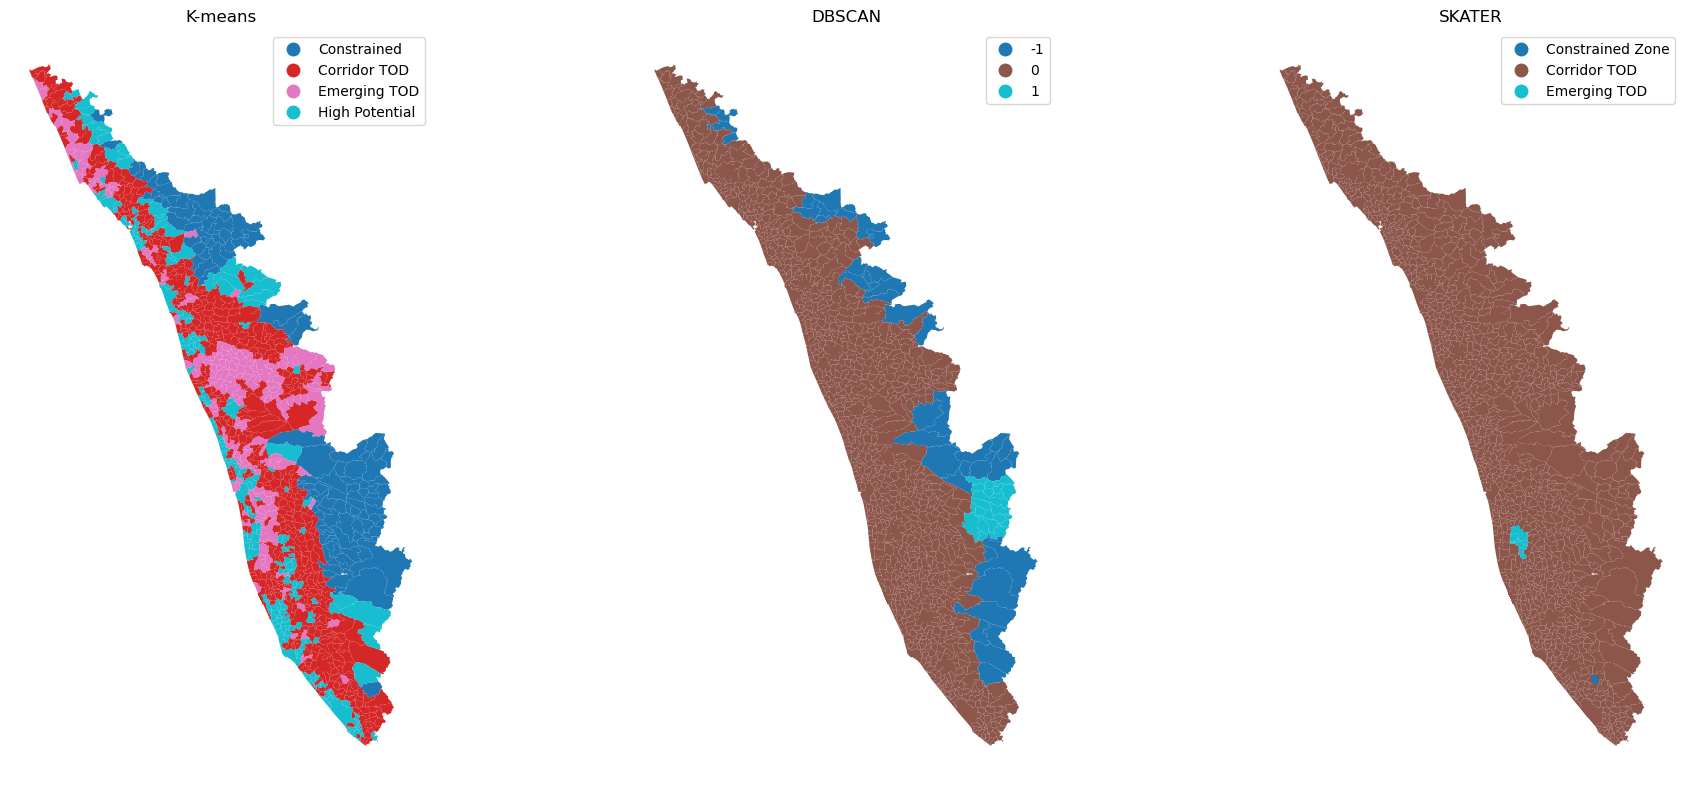

In [16]:
import geopandas as gpd
import pandas as pd
import numpy as np
import libpysal
from spopt.region import Skater
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import warnings
import os

warnings.filterwarnings("ignore")

# ============================================================
# FILE PATHS
# ============================================================

master_csv = r"D:\MPLAN\thesis\objective 2\kerala_TSI_all_clusters_afterremovingduplicates.csv"

# IMPORTANT: Give actual shapefile (.shp)
shape_file = r"D:\MPLAN\thesis\objective 2\Export_LSGD.shp"

output_folder = r"D:\MPLAN\thesis\objective 2"
os.makedirs(output_folder, exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

print("Loading data...")

master = pd.read_csv(master_csv)

gdf = gpd.read_file(shape_file)
gdf = gdf.to_crs("EPSG:32643")

# Merge
gdf = gdf.merge(master, on="Name_1", how="left")

# Required indicators
ind_cols = ['I1','I2','I3','I4','I5','I6']

# Fill missing values
for col in ind_cols:
    gdf[col] = gdf[col].fillna(0)

gdf['TSI_score'] = gdf['TSI_score'].fillna(0)

X = gdf[ind_cols].values

print(f"Loaded {len(gdf)} panchayats")


master = pd.read_csv(master_csv)

# Remove spaces from column names
master.columns = master.columns.str.strip()

print("CSV columns:")
print(master.columns.tolist())

# Required indicators
ind_cols = ['I1','I2','I3','I4','I5','I6']

# Check missing columns
missing_cols = [col for col in ind_cols if col not in master.columns]

if len(missing_cols) > 0:
    print("Missing columns:", missing_cols)
else:
    print("All indicators found")

# ============================================================
# METHOD 1 — KMEANS
# ============================================================

print("\n[1/3] Running K-means...")

sil_scores = {}

for k in range(3, 8):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = km.fit_predict(X)

    sil = silhouette_score(X, labels)

    sil_scores[k] = sil

    print(f"k={k}: silhouette={sil:.4f}")

best_k = max(sil_scores, key=sil_scores.get)

print(f"\nBest K = {best_k}")

km_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

gdf['cluster_kmeans'] = km_final.fit_predict(X)

# Name clusters
cluster_means = (
    gdf.groupby("cluster_kmeans")['TSI_score']
    .mean()
    .sort_values()
)

cluster_names = [
    'Constrained',
    'Emerging TOD',
    'Corridor TOD',
    'High Potential',
    'Primary TOD Hub'
][:best_k]

name_map = {}

for rank, cid in enumerate(cluster_means.index):
    name_map[cid] = cluster_names[rank]

gdf['kmeans_label'] = gdf['cluster_kmeans'].map(name_map)

# ============================================================
# METHOD 2 — DBSCAN
# ============================================================

print("\n[2/3] Running DBSCAN...")

# Panchayat centroids
centroids = gdf.geometry.centroid

coords = np.column_stack([
    centroids.x.values / 1000,
    centroids.y.values / 1000
])

# Add TSI weighting
tsi_scaled = (
    gdf['TSI_score'].values.reshape(-1,1)
    * 15
)

X_dbscan = np.hstack([
    coords,
    tsi_scaled
])

db = DBSCAN(
    eps=10,
    min_samples=5
)

gdf['cluster_dbscan'] = db.fit_predict(X_dbscan)

n_clusters_db = len(set(gdf['cluster_dbscan'])) - (
    1 if -1 in gdf['cluster_dbscan'].values else 0
)

noise_points = list(
    gdf['cluster_dbscan']
).count(-1)

print(f"Clusters found: {n_clusters_db}")
print(f"Noise points: {noise_points}")

# Name DBSCAN clusters
valid_db = gdf[gdf['cluster_dbscan'] >= 0]

if len(valid_db) > 0:

    db_means = (
        valid_db.groupby("cluster_dbscan")['TSI_score']
        .mean()
        .sort_values(ascending=False)
    )

    db_name_map = {}

    for i, cid in enumerate(db_means.index):
        db_name_map[cid] = f"Corridor {i+1}"

    db_name_map[-1] = "Noise"

    gdf['dbscan_label'] = (
        gdf['cluster_dbscan']
        .map(db_name_map)
    )

# ============================================================
# METHOD 3 — SKATER
# ============================================================

print("\n[3/3] Running SKATER...")

gdf_clean = gdf.copy().reset_index(drop=True)

# Spatial weights
w = libpysal.weights.Queen.from_dataframe(gdf_clean)

print(f"Disconnected islands: {len(w.islands)}")

# Remove islands if any
if len(w.islands) > 0:

    keep = [
        i for i in range(len(gdf_clean))
        if i not in w.islands
    ]

    gdf_skater = (
        gdf_clean.iloc[keep]
        .reset_index(drop=True)
    )

    w = libpysal.weights.Queen.from_dataframe(
        gdf_skater
    )

else:

    gdf_skater = gdf_clean.copy()

skater_results = {}

for k in range(3, 7):

    try:

        model = Skater(
            gdf_skater,
            w,
            attrs_name=ind_cols,
            n_clusters=k,
            floor=2
        )

        model.solve()

        labels = model.labels_

        sil = silhouette_score(
            gdf_skater[ind_cols].values,
            labels
        )

        skater_results[k] = {
            "model": model,
            "labels": labels,
            "silhouette": sil
        }

        print(f"k={k}: silhouette={sil:.4f}")

    except Exception as e:

        print(f"k={k} failed: {e}")

best_k_skater = max(
    skater_results,
    key=lambda x: skater_results[x]['silhouette']
)

best_skater = skater_results[best_k_skater]

gdf_skater['cluster_skater'] = (
    best_skater['labels']
)

# Name clusters
sk_means = (
    gdf_skater.groupby("cluster_skater")['TSI_score']
    .mean()
    .sort_values()
)

sk_names = [
    'Constrained Zone',
    'Emerging TOD',
    'Corridor TOD',
    'High Potential TOD',
    'Primary TOD Hub'
][:best_k_skater]

sk_name_map = {}

for rank, cid in enumerate(sk_means.index):
    sk_name_map[cid] = sk_names[rank]

gdf_skater['skater_label'] = (
    gdf_skater['cluster_skater']
    .map(sk_name_map)
)

# ============================================================
# VISUALIZATION
# ============================================================

print("\nCreating maps...")

fig, axes = plt.subplots(
    1, 3,
    figsize=(20,8)
)

# Kmeans
gdf.plot(
    column='kmeans_label',
    categorical=True,
    legend=True,
    ax=axes[0]
)
axes[0].set_title("K-means")
axes[0].axis("off")

# DBSCAN
gdf.plot(
    column='cluster_dbscan',
    categorical=True,
    legend=True,
    ax=axes[1]
)
axes[1].set_title("DBSCAN")
axes[1].axis("off")

# SKATER
gdf_skater.plot(
    column='skater_label',
    categorical=True,
    legend=True,
    ax=axes[2]
)
axes[2].set_title("SKATER")
axes[2].axis("off")

plt.tight_layout()

map_path = os.path.join(
    output_folder,
    "clustering_comparison.png"
)

plt.savefig(
    map_path,
    dpi=300
)

# ============================================================
# EXPORT
# ============================================================

print("\nExporting...")

master_out = master.copy()

master_out = master_out.merge(
    gdf[['Name_1','cluster_kmeans','kmeans_label']],
    on='Name_1',
    how='left'
)

master_out = master_out.merge(
    gdf[['Name_1','cluster_dbscan','dbscan_label']],
    on='Name_1',
    how='left'
)

master_out = master_out.merge(
    gdf_skater[['Name_1','cluster_skater','skater_label']],
    on='Name_1',
    how='left'
)

csv_out = os.path.join(
    output_folder,
    r"D:\MPLAN\thesis\objective 2\kerala_TSI_all_clusters.csv"
)

master_out.to_csv(
    csv_out,
    index=False
)

# Spatial export
gpkg_out = os.path.join(
    output_folder,
    "kerala_TOD_all_clusters.gpkg"
)

gdf.to_file(
    gpkg_out,
    driver="GPKG"
)

print("\nDONE")
print(csv_out)
print(gpkg_out)
print(map_path)

In [14]:
# Check for duplicate Name_1 in each dataframe
print("master_out duplicates:", master_out['Name_1'].duplicated().sum())
print("gdf duplicates:", gdf['Name_1'].duplicated().sum())
print("gdf_skater duplicates:", gdf_skater['Name_1'].duplicated().sum())

# See which names are duplicated
dupes = gdf_skater[gdf_skater['Name_1'].duplicated(keep=False)]
print("\nDuplicate Name_1 values in gdf_skater:")
print(dupes[['Name_1','cluster_skater','skater_label']].head(20))

master_out duplicates: 7340025
gdf duplicates: 889
gdf_skater duplicates: 889

Duplicate Name_1 values in gdf_skater:
        Name_1  cluster_skater  skater_label
37  Valanchery               0  Corridor TOD
38  Valanchery               0  Corridor TOD
39  Valanchery               0  Corridor TOD
40  Valanchery               0  Corridor TOD
41  Valanchery               0  Corridor TOD
42  Valanchery               0  Corridor TOD
43  Valanchery               0  Corridor TOD
44  Valanchery               0  Corridor TOD
45  Valanchery               0  Corridor TOD
46  Valanchery               0  Corridor TOD
47  Valanchery               0  Corridor TOD
48  Valanchery               0  Corridor TOD
49  Valanchery               0  Corridor TOD
50  Valanchery               0  Corridor TOD
51  Valanchery               0  Corridor TOD
52  Valanchery               0  Corridor TOD
53  Valanchery               0  Corridor TOD
54  Valanchery               0  Corridor TOD
55  Valanchery             

In [15]:
# ── SAFE EXPORT — avoids duplicate Name_1 memory explosion ───

# Step 1: Keep only the columns needed from each method
# Use index-based merge to avoid Name_1 duplicates

# Reset gdf index to ensure clean merge
gdf = gdf.reset_index(drop=True)
gdf_skater = gdf_skater.reset_index(drop=True)

# Add a unique row ID to master based on position
master_out = master.copy()
master_out = master_out.reset_index(drop=True)

# For K-means and DBSCAN — these are already on full gdf
# Keep only unique Name_1 rows (take first occurrence)
kmeans_cols = (gdf[['Name_1','cluster_kmeans','kmeans_label']]
               .drop_duplicates(subset='Name_1', keep='first'))

dbscan_cols = (gdf[['Name_1','cluster_dbscan','dbscan_label']]
               .drop_duplicates(subset='Name_1', keep='first'))

skater_cols = (gdf_skater[['Name_1','cluster_skater','skater_label']]
               .drop_duplicates(subset='Name_1', keep='first'))

# Merge one at a time with validate to catch issues
print(f"master_out rows: {len(master_out)}")
print(f"kmeans_cols rows: {len(kmeans_cols)}")
print(f"dbscan_cols rows: {len(dbscan_cols)}")
print(f"skater_cols rows: {len(skater_cols)}")

master_out = master_out.merge(kmeans_cols, on='Name_1', how='left')
print(f"After kmeans merge: {len(master_out)} rows")

master_out = master_out.merge(dbscan_cols, on='Name_1', how='left')
print(f"After dbscan merge: {len(master_out)} rows")

master_out = master_out.merge(skater_cols, on='Name_1', how='left')
print(f"After skater merge: {len(master_out)} rows")

# If row count explodes at any merge — that merge has duplicates
# The print statements above will show you which one

# Save CSV
master_out.to_csv(r"D:\MPLAN\thesis\objective 2\kerala_TSI_all_clusters_afterremovingduplicates.csv", index=False)
print("Saved: kerala_TSI_all_clusters.csv")

master_out rows: 1468
kmeans_cols rows: 1027
dbscan_cols rows: 1027
skater_cols rows: 1027
After kmeans merge: 1468 rows
After dbscan merge: 1468 rows
After skater merge: 1468 rows
Saved: kerala_TSI_all_clusters.csv


In [10]:
import geopandas as gpd
import pandas as pd
import numpy as np
import libpysal
from spopt.region import Skater
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import warnings
import os

warnings.filterwarnings("ignore")

# ============================================================
# FILE PATHS
# ============================================================

master_csv = r"D:\MPLAN\thesis\objective 2\kerala_TSI_fixed_indicators.csv"

# IMPORTANT: Give actual shapefile (.shp)
shape_file = r"D:\MPLAN\thesis\objective 2\Export_LSGD.shp"

output_folder = r"D:\MPLAN\thesis\objective 2"
os.makedirs(output_folder, exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

print("Loading data...")

master = pd.read_csv(master_csv)

gdf = gpd.read_file(shape_file)
gdf = gdf.to_crs("EPSG:32643")

# Merge
gdf = gdf.merge(master, on="Name_1", how="left")

# Required indicators
ind_cols = ['I1','I2','I3','I4','I5','I6']

# Fill missing values
for col in ind_cols:
    gdf[col] = gdf[col].fillna(0)

gdf['TSI_score'] = gdf['TSI_score'].fillna(0)

X = gdf[ind_cols].values

print(f"Loaded {len(gdf)} panchayats")


master = pd.read_csv(master_csv)

# Remove spaces from column names
master.columns = master.columns.str.strip()

print("CSV columns:")
print(master.columns.tolist())

# Required indicators
ind_cols = ['I1','I2','I3','I4','I5','I6']

# Check missing columns
missing_cols = [col for col in ind_cols if col not in master.columns]

if len(missing_cols) > 0:
    print("Missing columns:", missing_cols)
else:
    print("All indicators found")



Loading data...


KeyError: 'I3'

In [12]:
import geopandas as gpd
import pandas as pd

# Load both files
master = pd.read_csv(r"D:\MPLAN\thesis\objective 2\kerala_TSI_corrected.csv")
gdf    = gpd.read_file(r"D:\MPLAN\thesis\objective 2\Export_LSGD.shp").to_crs('EPSG:32643')
gdf    = gdf.merge(master, on='Name_1', how='left')

# Print all column names
print("All columns in merged GDF:")
print(gdf.columns.tolist())

print("\nCSV columns:")
print(master.columns.tolist())

All columns in merged GDF:
['name_ml', 'Name_1', 'AREA', 'Name', 'CRZ_Zone_1', 'Value', 'OBJECTID', 'Area_1', 'Built_norm', 'geometry', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'TSI_original', 'TSI_capped', 'TSI_equal', 'TSI_score', 'TSI_class', 'TOD_cluster', 'cluster_id']

CSV columns:
['Name_1', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'TSI_original', 'TSI_capped', 'TSI_equal', 'TSI_score', 'TSI_class', 'TOD_cluster', 'cluster_id']


In [25]:
import geopandas as gpd
import pandas as pd
import numpy as np
import libpysal
from spopt.region import Skater
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
import gc
import os
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════
#  CONFIGURATION — edit these paths only
# ══════════════════════════════════════════════════════════════
MASTER_CSV  = r"D:\MPLAN\thesis\objective 2\kerala_TSI_all_clusters_afterremovingduplicates.csv"
SHAPEFILE   = r"D:\MPLAN\thesis\objective 2\Export_LSGD.shp"
OUTPUT_DIR  = '.'           # folder where outputs are saved
N_CLUSTERS  = 5             # desired number of clusters for K-means and SKATER

# Theory-based weights — justified by literature
# I1 transit proximity 0.25  (Guerra & Cervero 2011)
# I4 economic intensity 0.20 (Henderson et al. 2012)
# I2, I3, I5 equal at 0.15
# I6 walkability lowest 0.10 (prevents I6 dominance)
W_THEORY = np.array([0.25, 0.15, 0.15, 0.20, 0.15, 0.10])

# Cluster names ordered from lowest to highest TSI mean
CLUSTER_NAMES  = ['Constrained','Emerging TOD','Corridor TOD',
                  'High Potential TOD','Primary TOD Hub']
CLUSTER_COLORS = ['#888780','#EF9F27','#1D9E75','#378ADD','#534AB7']

print("=" * 65)
print("  TOD CLUSTERING — ALL THREE METHODS")
print("  K-means  |  DBSCAN  |  SKATER")
print("=" * 65)

# ══════════════════════════════════════════════════════════════
#  STEP 1 — Load and prepare data
# ══════════════════════════════════════════════════════════════
print("\n[1/7] Loading data...")

master = pd.read_csv(MASTER_CSV)
gdf    = gpd.read_file(SHAPEFILE).to_crs('EPSG:32643')
gdf    = gdf.merge(master, on='Name_1', how='left')

# ── Auto-detect indicator columns ────────────────────────────
searches = {
    'I1': ['I1','I1_norm','I1_NORM','i1_norm','I1_raw'],
    'I2': ['I2','I2_norm','I2_NORM','i2_norm','I2_raw'],
    'I3': ['I3','I3_norm','I3_NORM','Built_norm','i3_norm'],
    'I4': ['I4','I4_norm','I4_NORM','I4_economic','i4_norm'],
    'I5': ['I5','I5_norm','I5_NORM','I5_diversity','i5_norm'],
    'I6': ['I6','I6_norm','I6_NORM','i6_norm','I6_raw'],
}
tsi_searches = ['TSI_score','TSI_capped','TSI_equal','tsi_score','TSI']

def find_col(df, patterns):
    for pat in patterns:
        matches = [c for c in df.columns if c.lower() == pat.lower()]
        if matches:
            return matches[0]
    return None

print("  Column detection:")
for std, pats in searches.items():
    found = find_col(gdf, pats)
    if found and found != std:
        gdf.rename(columns={found: std}, inplace=True)
        print(f"    {std} ← {found}")
    elif found:
        print(f"    {std} ← OK")
    else:
        print(f"    {std} ← NOT FOUND")

tsi_found = find_col(gdf, tsi_searches)
if tsi_found and tsi_found != 'TSI_score':
    gdf.rename(columns={tsi_found: 'TSI_score'}, inplace=True)
    print(f"    TSI_score ← {tsi_found}")

ind_cols = ['I1','I2','I3','I4','I5','I6']
missing  = [c for c in ind_cols + ['TSI_score'] if c not in gdf.columns]
if missing:
    raise SystemExit(f"Still missing columns: {missing}. "
                     f"Check your CSV column names.")

# ── Clean and clip ────────────────────────────────────────────
for col in ind_cols:
    gdf[col] = pd.to_numeric(gdf[col], errors='coerce')
    gdf[col] = gdf[col].fillna(gdf[col].median()).clip(0, 1)
gdf['TSI_score'] = pd.to_numeric(
    gdf['TSI_score'], errors='coerce').fillna(0)

# Add unique row ID to prevent duplicate-name merge explosion
gdf['_row_id'] = range(len(gdf))
master['_row_id'] = range(len(master))

X = gdf[ind_cols].values
n, m = X.shape

print(f"\n  Loaded {n} panchayats")
print("  Indicator ranges:")
for col in ind_cols:
    print(f"    {col}: {gdf[col].min():.4f} – {gdf[col].max():.4f}  "
          f"std={gdf[col].std():.4f}")

# ── Weighted feature matrix (theory weights) ─────────────────
X_w = X * W_THEORY
print(f"\n  Theory weights: {dict(zip(ind_cols, W_THEORY))}")

# ══════════════════════════════════════════════════════════════
#  STEP 2 — K-MEANS
#  Uses theory-based weighted feature matrix
#  Forces k=5 AND finds silhouette-optimal k for comparison
# ══════════════════════════════════════════════════════════════
print("\n[2/7] K-means clustering...")

# Find silhouette-optimal k
sil_scores = {}
for k in range(3, 8):
    km   = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
    labs = km.fit_predict(X_w)
    sil_scores[k] = silhouette_score(X_w, labs)
    print(f"  k={k}  silhouette={sil_scores[k]:.4f}")

best_k_sil = max(sil_scores, key=sil_scores.get)
print(f"\n  Silhouette-optimal k = {best_k_sil}")
print(f"  Using k = {N_CLUSTERS} (theory-justified)")

# Run final K-means with N_CLUSTERS
km_final = KMeans(n_clusters=N_CLUSTERS, random_state=42,
                  n_init=20, max_iter=500)
gdf['cluster_kmeans'] = km_final.fit_predict(X_w)

# Name clusters by TSI mean (lowest=Constrained, highest=Primary TOD Hub)
tsi_rank = (gdf.groupby('cluster_kmeans')['TSI_score']
            .mean().sort_values())
name_map  = {cid: CLUSTER_NAMES[rank]
             for rank, cid in enumerate(tsi_rank.index)}
color_map = {cid: CLUSTER_COLORS[rank]
             for rank, cid in enumerate(tsi_rank.index)}
gdf['kmeans_label'] = gdf['cluster_kmeans'].map(name_map)
gdf['kmeans_color'] = gdf['cluster_kmeans'].map(color_map)

sil_kmeans = silhouette_score(X_w, gdf['cluster_kmeans'])
db_kmeans  = davies_bouldin_score(X_w, gdf['cluster_kmeans'])

print(f"\n  K-means k={N_CLUSTERS}:")
print(f"  Silhouette={sil_kmeans:.4f}  Davies-Bouldin={db_kmeans:.4f}")
print(f"\n  Cluster distribution:")
print(gdf['kmeans_label'].value_counts().to_string())

print("\n  Cluster profiles (mean indicator values):")
profile = (gdf.groupby('kmeans_label')[ind_cols + ['TSI_score']]
           .mean().round(3))
print(profile.to_string())

# ══════════════════════════════════════════════════════════════
#  STEP 3 — DBSCAN
#  Auto-tunes eps to find 3–8 meaningful corridors
# ══════════════════════════════════════════════════════════════
print("\n[3/7] DBSCAN spatial clustering (auto-tuning eps)...")

# Build spatial input: UTM coords in km + TSI score (moderate amplification)
coords    = np.column_stack([
    gdf.geometry.centroid.x.values / 1000,
    gdf.geometry.centroid.y.values / 1000
])
tsi_amp   = gdf['TSI_score'].values.reshape(-1, 1) * 5   # reduced from 15 to 5
X_dbscan  = np.hstack([coords, tsi_amp])

# Auto-tune eps
print("\n  Tuning eps parameter:")
best_eps    = 5
best_n_cl   = 0
eps_results = {}

for eps_val in [2, 3, 4, 5, 6, 8, 10, 12]:
    db_test  = DBSCAN(eps=eps_val, min_samples=3).fit(X_dbscan)
    n_cl     = len(set(db_test.labels_)) - (1 if -1 in db_test.labels_ else 0)
    n_noise  = list(db_test.labels_).count(-1)
    eps_results[eps_val] = {'n_clusters': n_cl, 'n_noise': n_noise}
    print(f"  eps={eps_val:4.0f}: {n_cl} clusters  {n_noise} noise points")

    # Target: 3–8 clusters with <30% noise
    noise_frac = n_noise / len(gdf)
    if 3 <= n_cl <= 8 and noise_frac < 0.30:
        if n_cl > best_n_cl:
            best_n_cl  = n_cl
            best_eps   = eps_val

print(f"\n  Selected eps = {best_eps} → {best_n_cl} clusters")

# Final DBSCAN run
db_final = DBSCAN(eps=best_eps, min_samples=3).fit(X_dbscan)
gdf['cluster_dbscan'] = db_final.labels_

n_clusters_db = len(set(db_final.labels_)) - (1 if -1 in db_final.labels_ else 0)
n_noise       = list(db_final.labels_).count(-1)

# Name DBSCAN clusters by mean TSI (descending)
valid_mask    = gdf['cluster_dbscan'] >= 0
db_tsi        = (gdf[valid_mask]
                 .groupby('cluster_dbscan')['TSI_score']
                 .mean().sort_values(ascending=False))
# FIXED — generates names dynamically for any number of clusters
db_name_map = {}
for i, cid in enumerate(db_tsi.index):
    if i == 0:
        db_name_map[cid] = 'Primary Corridor'
    elif i == 1:
        db_name_map[cid] = 'High Potential Corridor'
    elif i == 2:
        db_name_map[cid] = 'Moderate Corridor'
    elif i == 3:
        db_name_map[cid] = 'Emerging Corridor'
    else:
        db_name_map[cid] = f'Corridor {i+1}'   # handles any extra clusters

db_name_map[-1] = 'Isolated / Noise'
gdf['dbscan_label'] = gdf['cluster_dbscan'].map(db_name_map)
gdf['dbscan_label'] = gdf['cluster_dbscan'].map(db_name_map)

print(f"\n  DBSCAN: {n_clusters_db} spatial corridors  "
      f"{n_noise} noise panchayats ({n_noise/len(gdf)*100:.1f}%)")
print(gdf['dbscan_label'].value_counts().to_string())

# ══════════════════════════════════════════════════════════════
#  STEP 4 — SKATER
#  Spatially constrained clustering — produces contiguous zones
# ══════════════════════════════════════════════════════════════
print("\n[4/7] SKATER spatially constrained clustering...")

# Remove nulls and reset index
gdf_skater = gdf[ind_cols + ['Name_1','TSI_score','_row_id',
                              'geometry']].dropna().copy()
gdf_skater = gdf_skater.reset_index(drop=True)
print(f"  Working with {len(gdf_skater)} panchayats")

# Build Queen contiguity weights
print("  Building Queen contiguity weights...")
w = libpysal.weights.Queen.from_dataframe(gdf_skater)
w.transform = 'r'
print(f"  Islands: {len(w.islands)}")

# Remove islands
if len(w.islands) > 0:
    keep = [i for i in range(len(gdf_skater)) if i not in w.islands]
    gdf_skater = gdf_skater.iloc[keep].reset_index(drop=True)
    w = libpysal.weights.Queen.from_dataframe(gdf_skater)
    w.transform = 'r'
    print(f"  After removing islands: {len(gdf_skater)} panchayats")

# Run SKATER for k = 3 to 6, pick best silhouette
print(f"  Running SKATER for k = 3 to {N_CLUSTERS}...")
skater_results = {}

for k in range(3, N_CLUSTERS + 1):
    try:
        model = Skater(
            gdf_skater, w,
            attrs_name=ind_cols,
            n_clusters=k,
            floor=5           # minimum 5 panchayats per region
        )
        model.solve()
        labels = model.labels_
        sil    = silhouette_score(gdf_skater[ind_cols].values, labels)
        skater_results[k] = {'labels': labels, 'silhouette': sil}
        print(f"  k={k}  silhouette={sil:.4f}")
    except Exception as e:
        print(f"  k={k}  failed: {e}")

if not skater_results:
    print("  SKATER failed for all k. Using spatial K-means fallback...")

    # Fallback: K-means with spatial lag
    lag_features = np.column_stack([
        libpysal.weights.lag_spatial(w, gdf_skater[ind_cols].values[:, i])
        for i in range(len(ind_cols))
    ])
    X_lag = np.hstack([
        gdf_skater[ind_cols].values,
        lag_features
    ])
    X_lag_norm = MinMaxScaler().fit_transform(X_lag)

    sil_lag = {}
    for k in range(3, N_CLUSTERS + 1):
        km_lag   = KMeans(n_clusters=k, random_state=42, n_init=15)
        labs_lag = km_lag.fit_predict(X_lag_norm)
        sil_lag[k] = silhouette_score(X_lag_norm, labs_lag)
        print(f"  Spatial KMeans k={k}  silhouette={sil_lag[k]:.4f}")

    best_k_lag = max(sil_lag, key=sil_lag.get)
    km_lag_final = KMeans(n_clusters=best_k_lag, random_state=42, n_init=15)
    gdf_skater['cluster_skater'] = km_lag_final.fit_predict(X_lag_norm)
    best_k_skater = best_k_lag
    best_sil_skater = sil_lag[best_k_lag]
    print(f"  Fallback k={best_k_lag}  silhouette={best_sil_skater:.4f}")

else:
    # Pick best k from SKATER results
    best_k_skater   = max(skater_results, key=lambda k: skater_results[k]['silhouette'])
    best_sil_skater = skater_results[best_k_skater]['silhouette']
    gdf_skater['cluster_skater'] = skater_results[best_k_skater]['labels']
    print(f"\n  SKATER best k = {best_k_skater}  "
          f"silhouette = {best_sil_skater:.4f}")

# Name SKATER clusters by TSI mean
sk_tsi   = (gdf_skater.groupby('cluster_skater')['TSI_score']
            .mean().sort_values())
sk_names_use  = CLUSTER_NAMES[:best_k_skater]
sk_colors_use = CLUSTER_COLORS[:best_k_skater]
sk_name_map   = {cid: sk_names_use[rank]
                 for rank, cid in enumerate(sk_tsi.index)}
sk_color_map  = {cid: sk_colors_use[rank]
                 for rank, cid in enumerate(sk_tsi.index)}
gdf_skater['skater_label'] = gdf_skater['cluster_skater'].map(sk_name_map)
gdf_skater['skater_color'] = gdf_skater['cluster_skater'].map(sk_color_map)

print(f"\n  SKATER cluster distribution:")
print(gdf_skater['skater_label'].value_counts().to_string())

# ══════════════════════════════════════════════════════════════
#  STEP 5 — VISUALISE ALL THREE MAPS
# ══════════════════════════════════════════════════════════════
print("\n[5/7] Generating comparison maps...")

fig, axes = plt.subplots(1, 3, figsize=(22, 14))
fig.patch.set_facecolor('white')

# ── Map 1: K-means ───────────────────────────────────────────
ax = axes[0]
for label, color in zip(CLUSTER_NAMES[:N_CLUSTERS], CLUSTER_COLORS[:N_CLUSTERS]):
    subset = gdf[gdf['kmeans_label'] == label]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, linewidth=0.08,
                   edgecolor='white', label=label)

# Panchayats with no label
no_label = gdf[gdf['kmeans_label'].isna()]
if len(no_label) > 0:
    no_label.plot(ax=ax, color='#CCCCCC', linewidth=0.08, edgecolor='white')

ax.set_title(f'Method 1 — K-means\n'
             f'k={N_CLUSTERS} (theory weights) | '
             f'Silhouette={sil_kmeans:.3f}',
             fontsize=10, fontweight='bold', pad=8)
ax.set_axis_off()

handles = [mpatches.Patch(color=CLUSTER_COLORS[i], label=CLUSTER_NAMES[i])
           for i in range(N_CLUSTERS)]
ax.legend(handles=handles, loc='lower left', fontsize=7.5,
          framealpha=0.9, edgecolor='#CCCCCC')

# ── Map 2: DBSCAN ────────────────────────────────────────────
ax = axes[1]
dbscan_palette = plt.cm.tab10(np.linspace(0, 1, max(n_clusters_db, 1)))

# Plot noise first (grey background)
noise = gdf[gdf['cluster_dbscan'] == -1]
if len(noise) > 0:
    noise.plot(ax=ax, color='#DDDDDD', linewidth=0.08, edgecolor='white',
               label='Isolated / Noise')

# Plot each corridor
db_handles = [mpatches.Patch(color='#DDDDDD', label='Isolated / Noise')]
for i, (cid, cname) in enumerate(
    sorted(db_name_map.items(), key=lambda x: x[0])
):
    if cid < 0:
        continue
    subset = gdf[gdf['cluster_dbscan'] == cid]
    color  = dbscan_palette[i % len(dbscan_palette)]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, linewidth=0.08, edgecolor='white')
        db_handles.append(mpatches.Patch(color=color, label=cname))

ax.set_title(f'Method 2 — DBSCAN\n'
             f'{n_clusters_db} spatial corridors | '
             f'eps={best_eps} | {n_noise} noise pts',
             fontsize=10, fontweight='bold', pad=8)
ax.set_axis_off()
ax.legend(handles=db_handles, loc='lower left', fontsize=7.5,
          framealpha=0.9, edgecolor='#CCCCCC')

# ── Map 3: SKATER ────────────────────────────────────────────
ax = axes[2]

# Plot all panchayats grey first (for islands/missing)
gdf.plot(ax=ax, color='#EEEEEE', linewidth=0.05, edgecolor='white')

sk_handles = []
for label, color in zip(sk_names_use, sk_colors_use):
    subset = gdf_skater[gdf_skater['skater_label'] == label]
    if len(subset) > 0:
        subset.plot(ax=ax, color=color, linewidth=0.08, edgecolor='white')
        sk_handles.append(mpatches.Patch(color=color, label=label))

ax.set_title(f'Method 3 — SKATER\n'
             f'k={best_k_skater} (spatially contiguous) | '
             f'Silhouette={best_sil_skater:.3f}',
             fontsize=10, fontweight='bold', pad=8)
ax.set_axis_off()
ax.legend(handles=sk_handles, loc='lower left', fontsize=7.5,
          framealpha=0.9, edgecolor='#CCCCCC')

fig.suptitle('TOD Cluster Method Comparison — Kerala Panchayats\n'
             'K-means (attribute) | DBSCAN (spatial density) | '
             'SKATER (spatially constrained)',
             fontsize=12, fontweight='bold', y=0.99)

plt.tight_layout(rect=[0, 0, 1, 0.97])
out_map = os.path.join(OUTPUT_DIR, 'clustering_comparison_maps.png')
plt.savefig(out_map, dpi=200, bbox_inches='tight', facecolor='white')
plt.close()
print(f"  Saved: {out_map}")

# ══════════════════════════════════════════════════════════════
#  STEP 6 — COMPARISON SUMMARY TABLE
# ══════════════════════════════════════════════════════════════
print("\n[6/7] Method comparison summary:")
print("=" * 65)
print(f"  K-means:  k={N_CLUSTERS}  silhouette={sil_kmeans:.4f}  "
      f"DB={db_kmeans:.4f}  (theory-weighted)")
print(f"  DBSCAN:   {n_clusters_db} corridors  "
      f"{n_noise} noise ({n_noise/len(gdf)*100:.1f}%)  "
      f"eps={best_eps}")
print(f"  SKATER:   k={best_k_skater}  "
      f"silhouette={best_sil_skater:.4f}  "
      f"(spatially contiguous)")
print("=" * 65)
print("\n  Recommendation:")
print("  → Use K-means labels for TOD typology and FSI matrix (OBJ:3)")
print("  → Use DBSCAN map for corridor identification in results chapter")
print("  → Use SKATER map for structure plan zone boundaries")

# ══════════════════════════════════════════════════════════════
#  EXPORT — simplified, no _row_id dependency
# ══════════════════════════════════════════════════════════════
print("\n[7/7] Exporting results...")
import gc
gc.collect()

# ── Step 1: Extract cluster labels from gdf ───────────────────
# Keep only Name_1 + cluster columns, take first occurrence per name
kmeans_export = (gdf[['Name_1','cluster_kmeans','kmeans_label']]
                 .copy()
                 .drop_duplicates(subset='Name_1', keep='first')
                 .reset_index(drop=True))

dbscan_export = (gdf[['Name_1','cluster_dbscan','dbscan_label']]
                 .copy()
                 .drop_duplicates(subset='Name_1', keep='first')
                 .reset_index(drop=True))

skater_export = (gdf_skater[['Name_1','cluster_skater','skater_label']]
                 .copy()
                 .drop_duplicates(subset='Name_1', keep='first')
                 .reset_index(drop=True))

print(f"  kmeans_export: {len(kmeans_export)} rows")
print(f"  dbscan_export: {len(dbscan_export)} rows")
print(f"  skater_export: {len(skater_export)} rows")

# Verify kmeans_label exists
print(f"  kmeans columns: {kmeans_export.columns.tolist()}")
print(f"  kmeans sample:\n{kmeans_export.head(3)}")

# ── Step 2: Build output CSV from scratch ─────────────────────
result = pd.read_csv(MASTER_CSV)
print(f"\n  Base CSV rows: {len(result)}")

# Merge one at a time — Name_1 deduplicated so no memory explosion
result = result.merge(
    kmeans_export[['Name_1','kmeans_label','cluster_kmeans']],
    on='Name_1', how='left'
)
print(f"  kmeans merged — kmeans_label nulls: "
      f"{result['kmeans_label'].isna().sum()}")

result = result.merge(
    dbscan_export[['Name_1','dbscan_label','cluster_dbscan']],
    on='Name_1', how='left'
)
print(f"  dbscan merged — dbscan_label nulls: "
      f"{result['dbscan_label'].isna().sum()}")

result = result.merge(
    skater_export[['Name_1','skater_label','cluster_skater']],
    on='Name_1', how='left'
)
print(f"  skater merged — skater_label nulls: "
      f"{result['skater_label'].isna().sum()}")

print(f"\n  Final rows: {len(result)} — should be {len(pd.read_csv(MASTER_CSV))}")

# ── Step 3: Save CSV ──────────────────────────────────────────
out_csv = os.path.join(OUTPUT_DIR, 'kerala_TSI_all_clusters.csv')
result.to_csv(out_csv, index=False)
print(f"  Saved CSV: {out_csv}")

# ── Step 4: Save GeoPackage ───────────────────────────────────
# Build fresh from shapefile — no stale columns
gdf_export = gpd.read_file(SHAPEFILE).to_crs('EPSG:32643')

gdf_export = gdf_export.merge(
    result[['Name_1','TSI_score','kmeans_label','cluster_kmeans',
            'dbscan_label','cluster_dbscan',
            'skater_label','cluster_skater']],
    on='Name_1', how='left'
)

print(f"  GeoPackage rows: {len(gdf_export)}")
out_gpkg = os.path.join(OUTPUT_DIR, 'kerala_TOD_all_clusters.gpkg')
gdf_export.to_file(out_gpkg, driver='GPKG')
print(f"  Saved GPKG: {out_gpkg}")

# ── Step 5: Save SKATER zones separately ─────────────────────
out_sk = os.path.join(OUTPUT_DIR, 'kerala_TOD_skater_zones.gpkg')
gdf_skater.to_file(out_sk, driver='GPKG')
print(f"  Saved SKATER GPKG: {out_sk}")

print("\n" + "=" * 60)
print("  EXPORT COMPLETE")
print(f"  Outputs in: {OUTPUT_DIR}")
print("  Files created:")
print("  1. kerala_TSI_all_clusters.csv")
print("  2. kerala_TOD_all_clusters.gpkg")
print("  3. kerala_TOD_skater_zones.gpkg")
print("  4. clustering_comparison_maps.png")
print("\n  Use in ArcGIS:")
print("  kmeans_label  → TOD typology map + FSI matrix")
print("  dbscan_label  → corridor identification map")
print("  skater_label  → structure plan zone boundaries")
print("=" * 60)

  TOD CLUSTERING — ALL THREE METHODS
  K-means  |  DBSCAN  |  SKATER

[1/7] Loading data...
  Column detection:
    I1 ← OK
    I2 ← OK
    I3 ← OK
    I4 ← OK
    I5 ← OK
    I6 ← OK

  Loaded 1916 panchayats
  Indicator ranges:
    I1: 0.0000 – 1.0000  std=0.1336
    I2: 0.0000 – 1.0000  std=0.0751
    I3: 0.0000 – 0.5000  std=0.0546
    I4: 0.0209 – 0.7676  std=0.0638
    I5: 0.0000 – 1.0000  std=0.1731
    I6: 0.0000 – 1.0000  std=0.0525

  Theory weights: {'I1': np.float64(0.25), 'I2': np.float64(0.15), 'I3': np.float64(0.15), 'I4': np.float64(0.2), 'I5': np.float64(0.15), 'I6': np.float64(0.1)}

[2/7] K-means clustering...
  k=3  silhouette=0.3121
  k=4  silhouette=0.3524
  k=5  silhouette=0.3679
  k=6  silhouette=0.3654
  k=7  silhouette=0.3643

  Silhouette-optimal k = 5
  Using k = 5 (theory-justified)

  K-means k=5:
  Silhouette=0.3679  Davies-Bouldin=0.9195

  Cluster distribution:
kmeans_label
High Potential TOD    690
Emerging TOD          577
Corridor TOD          388
Pr

KeyError: 'kmeans_label'

In [26]:
import pandas as pd
import geopandas as gpd
import os
import gc
gc.collect()

# ── Find actual column names in gdf ──────────────────────────
print("Columns in gdf:")
print(gdf.columns.tolist())

# Auto-find cluster label columns regardless of exact name
def find_cluster_col(df, keywords):
    """Find column containing all keywords (case-insensitive)."""
    for col in df.columns:
        col_lower = col.lower()
        if all(k.lower() in col_lower for k in keywords):
            return col
    return None

# Search for each cluster label column
kmeans_label_col  = find_cluster_col(gdf, ['kmeans','label'])
kmeans_id_col     = find_cluster_col(gdf, ['kmeans','cluster'])
dbscan_label_col  = find_cluster_col(gdf, ['dbscan','label'])
dbscan_id_col     = find_cluster_col(gdf, ['dbscan','cluster'])

if not kmeans_label_col:
    # Try alternate patterns
    kmeans_label_col = find_cluster_col(gdf, ['label'])
    
print(f"\nDetected columns:")
print(f"  K-means label col : {kmeans_label_col}")
print(f"  K-means id col    : {kmeans_id_col}")
print(f"  DBSCAN label col  : {dbscan_label_col}")
print(f"  DBSCAN id col     : {dbscan_id_col}")

# Check gdf_skater too
print(f"\nColumns in gdf_skater:")
print(gdf_skater.columns.tolist())

skater_label_col = find_cluster_col(gdf_skater, ['skater','label'])
skater_id_col    = find_cluster_col(gdf_skater, ['skater','cluster'])
print(f"  SKATER label col  : {skater_label_col}")
print(f"  SKATER id col     : {skater_id_col}")

Columns in gdf:
['name_ml', 'Name_1', 'AREA', 'Name', 'CRZ_Zone_1', 'Value', 'OBJECTID', 'Area_1', 'Built_norm', 'geometry', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'TSI_score', 'TSI_class', 'TOD_cluster', 'cluster_id', 'cluster_kmeans', 'kmeans_label', 'cluster_dbscan', 'dbscan_label', 'cluster_skater', 'skater_label', '_row_id', 'kmeans_color']

Detected columns:
  K-means label col : kmeans_label
  K-means id col    : cluster_kmeans
  DBSCAN label col  : dbscan_label
  DBSCAN id col     : cluster_dbscan

Columns in gdf_skater:
['I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'Name_1', 'TSI_score', '_row_id', 'geometry', 'cluster_skater', 'skater_label', 'skater_color']
  SKATER label col  : skater_label
  SKATER id col     : cluster_skater


In [27]:
import pandas as pd
import geopandas as gpd
import os
import gc
gc.collect()

# ── Find actual column names in gdf ──────────────────────────
print("Columns in gdf:")
print(gdf.columns.tolist())

# Auto-find cluster label columns regardless of exact name
def find_cluster_col(df, keywords):
    """Find column containing all keywords (case-insensitive)."""
    for col in df.columns:
        col_lower = col.lower()
        if all(k.lower() in col_lower for k in keywords):
            return col
    return None

# Search for each cluster label column
kmeans_label_col  = find_cluster_col(gdf, ['kmeans','label'])
kmeans_id_col     = find_cluster_col(gdf, ['kmeans','cluster'])
dbscan_label_col  = find_cluster_col(gdf, ['dbscan','label'])
dbscan_id_col     = find_cluster_col(gdf, ['dbscan','cluster'])

if not kmeans_label_col:
    # Try alternate patterns
    kmeans_label_col = find_cluster_col(gdf, ['label'])
    
print(f"\nDetected columns:")
print(f"  K-means label col : {kmeans_label_col}")
print(f"  K-means id col    : {kmeans_id_col}")
print(f"  DBSCAN label col  : {dbscan_label_col}")
print(f"  DBSCAN id col     : {dbscan_id_col}")

# Check gdf_skater too
print(f"\nColumns in gdf_skater:")
print(gdf_skater.columns.tolist())

skater_label_col = find_cluster_col(gdf_skater, ['skater','label'])
skater_id_col    = find_cluster_col(gdf_skater, ['skater','cluster'])
print(f"  SKATER label col  : {skater_label_col}")
print(f"  SKATER id col     : {skater_id_col}")

Columns in gdf:
['name_ml', 'Name_1', 'AREA', 'Name', 'CRZ_Zone_1', 'Value', 'OBJECTID', 'Area_1', 'Built_norm', 'geometry', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'TSI_score', 'TSI_class', 'TOD_cluster', 'cluster_id', 'cluster_kmeans', 'kmeans_label', 'cluster_dbscan', 'dbscan_label', 'cluster_skater', 'skater_label', '_row_id', 'kmeans_color']

Detected columns:
  K-means label col : kmeans_label
  K-means id col    : cluster_kmeans
  DBSCAN label col  : dbscan_label
  DBSCAN id col     : cluster_dbscan

Columns in gdf_skater:
['I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'Name_1', 'TSI_score', '_row_id', 'geometry', 'cluster_skater', 'skater_label', 'skater_color']
  SKATER label col  : skater_label
  SKATER id col     : cluster_skater


In [28]:
# ── Rename to standard names ──────────────────────────────────
# Replace each None with the actual column name shown above

if kmeans_label_col and kmeans_label_col != 'kmeans_label':
    gdf = gdf.rename(columns={kmeans_label_col: 'kmeans_label'})
    print(f"Renamed {kmeans_label_col} → kmeans_label")

if kmeans_id_col and kmeans_id_col != 'cluster_kmeans':
    gdf = gdf.rename(columns={kmeans_id_col: 'cluster_kmeans'})
    print(f"Renamed {kmeans_id_col} → cluster_kmeans")

if dbscan_label_col and dbscan_label_col != 'dbscan_label':
    gdf = gdf.rename(columns={dbscan_label_col: 'dbscan_label'})
    print(f"Renamed {dbscan_label_col} → dbscan_label")

if dbscan_id_col and dbscan_id_col != 'cluster_dbscan':
    gdf = gdf.rename(columns={dbscan_id_col: 'cluster_dbscan'})
    print(f"Renamed {dbscan_id_col} → cluster_dbscan")

if skater_label_col and skater_label_col != 'skater_label':
    gdf_skater = gdf_skater.rename(columns={skater_label_col: 'skater_label'})
    print(f"Renamed {skater_label_col} → skater_label")

if skater_id_col and skater_id_col != 'cluster_skater':
    gdf_skater = gdf_skater.rename(columns={skater_id_col: 'cluster_skater'})
    print(f"Renamed {skater_id_col} → cluster_skater")

# ── Verify ────────────────────────────────────────────────────
needed = ['kmeans_label','cluster_kmeans',
          'dbscan_label','cluster_dbscan']
for col in needed:
    status = "✓ found" if col in gdf.columns else "✗ MISSING"
    print(f"  gdf['{col}']:  {status}")

sk_needed = ['skater_label','cluster_skater']
for col in sk_needed:
    status = "✓ found" if col in gdf_skater.columns else "✗ MISSING"
    print(f"  gdf_skater['{col}']:  {status}")

  gdf['kmeans_label']:  ✓ found
  gdf['cluster_kmeans']:  ✓ found
  gdf['dbscan_label']:  ✓ found
  gdf['cluster_dbscan']:  ✓ found
  gdf_skater['skater_label']:  ✓ found
  gdf_skater['cluster_skater']:  ✓ found


In [29]:
# ── Export once columns are confirmed ─────────────────────────
kmeans_export = (gdf[['Name_1','cluster_kmeans','kmeans_label']]
                 .drop_duplicates('Name_1', keep='first'))
dbscan_export  = (gdf[['Name_1','cluster_dbscan','dbscan_label']]
                 .drop_duplicates('Name_1', keep='first'))
skater_export  = (gdf_skater[['Name_1','cluster_skater','skater_label']]
                 .drop_duplicates('Name_1', keep='first'))

result = pd.read_csv(MASTER_CSV)
result = result.merge(kmeans_export, on='Name_1', how='left')
result = result.merge(dbscan_export,  on='Name_1', how='left')
result = result.merge(skater_export,  on='Name_1', how='left')

print(f"Final rows: {len(result)}")
print(f"Columns: {result.columns.tolist()}")

out_csv = os.path.join(OUTPUT_DIR, 'kerala_TSI_all_clusters.csv')
result.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")

# GeoPackage
gdf_export = gpd.read_file(SHAPEFILE).to_crs('EPSG:32643')
keep_cols  = ['Name_1','TSI_score',
              'kmeans_label','cluster_kmeans',
              'dbscan_label','cluster_dbscan',
              'skater_label','cluster_skater']
keep_cols  = [c for c in keep_cols if c in result.columns]
gdf_export = gdf_export.merge(result[keep_cols], on='Name_1', how='left')

out_gpkg = os.path.join(OUTPUT_DIR, 'kerala_TOD_all_clusters.gpkg')
gdf_export.to_file(out_gpkg, driver='GPKG')
print(f"Saved: {out_gpkg}")

gdf_skater.to_file(
    os.path.join(OUTPUT_DIR, 'kerala_TOD_skater_zones.gpkg'),
    driver='GPKG')
print("All exports complete")

Final rows: 1468
Columns: ['Name_1', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'TSI_score', 'TSI_class', 'TOD_cluster', 'cluster_id', 'cluster_kmeans_x', 'kmeans_label_x', 'cluster_dbscan_x', 'dbscan_label_x', 'cluster_skater_x', 'skater_label_x', 'cluster_kmeans_y', 'kmeans_label_y', 'cluster_dbscan_y', 'dbscan_label_y', 'cluster_skater_y', 'skater_label_y']
Saved: .\kerala_TSI_all_clusters.csv
Saved: .\kerala_TOD_all_clusters.gpkg
All exports complete


In [30]:
import pandas as pd

df = pd.read_csv('kerala_TSI_all_clusters.csv')

# Keep the _x version (first merge) and rename to clean names
rename_map = {}
drop_cols  = []

for suffix in ['kmeans_label','cluster_kmeans',
               'dbscan_label','cluster_dbscan',
               'skater_label','cluster_skater']:
    if f'{suffix}_x' in df.columns:
        rename_map[f'{suffix}_x'] = suffix
    if f'{suffix}_y' in df.columns:
        drop_cols.append(f'{suffix}_y')

df = df.rename(columns=rename_map)
df = df.drop(columns=drop_cols, errors='ignore')

print("Clean columns:", df.columns.tolist())
print("Rows:", len(df))

# Save clean version
df.to_csv('kerala_TSI_all_clusters_clean.csv', index=False)
print("Saved: kerala_TSI_all_clusters_clean.csv")
print("Location:", os.path.join(os.getcwd(), 'kerala_TSI_all_clusters_clean.csv'))

Clean columns: ['Name_1', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'TSI_score', 'TSI_class', 'TOD_cluster', 'cluster_id', 'cluster_kmeans', 'kmeans_label', 'cluster_dbscan', 'dbscan_label', 'cluster_skater', 'skater_label']
Rows: 1468
Saved: kerala_TSI_all_clusters_clean.csv
Location: C:\Users\DEVANSHI\kerala_TSI_all_clusters_clean.csv


In [31]:
import shutil
import os

# Your thesis folder
dest = r"D:\MPLAN\thesis\objective 2"

files_to_move = [
    'kerala_TSI_all_clusters_clean.csv',
    'kerala_TOD_all_clusters.gpkg',
    'kerala_TOD_skater_zones.gpkg',
    'clustering_comparison_maps.png',
]

for f in files_to_move:
    src = os.path.join(os.getcwd(), f)
    dst = os.path.join(dest, f)
    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"Moved: {f} → {dest}")
    else:
        print(f"Not found: {f}")

Moved: kerala_TSI_all_clusters_clean.csv → D:\MPLAN\thesis\objective 2
Moved: kerala_TOD_all_clusters.gpkg → D:\MPLAN\thesis\objective 2
Moved: kerala_TOD_skater_zones.gpkg → D:\MPLAN\thesis\objective 2
Moved: clustering_comparison_maps.png → D:\MPLAN\thesis\objective 2


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════
#  CONFIG — edit paths to match your files
# ══════════════════════════════════════════════════════════════
CLUSTERS_CSV = r"D:\MPLAN\thesis\objective 2\kerala_TSI_all_clusters_trial4.csv"
OUTPUT_DIR   = r"D:\MPLAN\thesis\objective 2"
IND_COLS     = ['I1','I2','I3','I4','I5','I6']
IND_LABELS   = ['Transit\nProximity','Bus Route\nDensity',
                'Built-up\nDensity','Economic\nIntensity',
                'LU\nDiversity','Walkability']
IND_SHORT    = ['I1\nTransit','I2\nBus','I3\nDensity',
                'I4\nEconomic','I5\nLULC','I6\nWalk']

# Theory weights used in clustering
W_THEORY = np.array([0.25, 0.15, 0.15, 0.20, 0.15, 0.10])

# Cluster colours — must match your map
CLUSTER_ORDER  = ['Constrained','Emerging TOD','Corridor TOD',
                  'High Potential TOD','Primary TOD Hub']
CLUSTER_COLORS = ['#888780','#EF9F27','#1D9E75','#378ADD','#534AB7']

print("Loading data...")
df = pd.read_csv(CLUSTERS_CSV)

# Ensure all indicator columns are numeric and clipped 0–1
for col in IND_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median()).clip(0, 1)

df['TSI_score'] = pd.to_numeric(
    df['TSI_score'], errors='coerce').fillna(0)

X = df[IND_COLS].values
n = len(df)

print(f"Loaded {n} panchayats")
print(f"Clusters present: {df['kmeans_label'].value_counts().to_dict()}")

# ══════════════════════════════════════════════════════════════
#  COMPUTE ENTROPY WEIGHTS (from your actual data)
# ══════════════════════════════════════════════════════════════
print("\nComputing entropy weights...")

P   = X / (X.sum(axis=0) + 1e-10)
lnP = np.where(P > 1e-10, np.log(P), 0)
E   = -(1/np.log(n)) * np.sum(P * lnP, axis=0)
d   = 1 - E
w_entropy = d / d.sum()

# Capped version — I6 capped at 0.25
w_capped = w_entropy.copy()
surplus  = max(0, w_capped[5] - 0.25)
w_capped[5] = 0.25
w_capped[0] += surplus * 0.5
w_capped[3] += surplus * 0.5
w_capped = w_capped / w_capped.sum()

print("Entropy weights (original):", dict(zip(IND_COLS, w_entropy.round(3))))
print("Theory weights:            ", dict(zip(IND_COLS, W_THEORY)))

# ══════════════════════════════════════════════════════════════
#  CLUSTER PROFILES — mean indicators per cluster
# ══════════════════════════════════════════════════════════════
# Only keep clusters that exist in the data
existing_clusters = [c for c in CLUSTER_ORDER
                     if c in df['kmeans_label'].values]
existing_colors   = [CLUSTER_COLORS[CLUSTER_ORDER.index(c)]
                     for c in existing_clusters]

cluster_means = (df.groupby('kmeans_label')[IND_COLS]
                 .mean()
                 .loc[[c for c in existing_clusters
                       if c in df.groupby('kmeans_label').groups]])
cluster_tsi   = df.groupby('kmeans_label')['TSI_score'].mean()

print("\nCluster profiles (mean indicator values):")
print(cluster_means.round(3).to_string())

# ══════════════════════════════════════════════════════════════
#  FIGURE — 3 charts in one figure (1 row × 3 columns)
# ══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 6.5))
fig.patch.set_facecolor('white')
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

TITLE_KW = dict(fontsize=11, fontweight='bold', pad=10)
CAP_KW   = dict(fontsize=8,  color='#666666')

# ══════════════════════════════════════════════════════════════
#  CHART 1 — Shannon Entropy Weights per Indicator
# ══════════════════════════════════════════════════════════════
ax1 = fig.add_subplot(gs[0])

x     = np.arange(len(IND_COLS))
width = 0.32

# Plot original entropy weights
bars_e = ax1.bar(x - width/2, w_entropy, width,
                 color='#E24B4A', alpha=0.85,
                 label='Entropy (original)',
                 edgecolor='white', linewidth=0.5)

# Plot theory weights
bars_t = ax1.bar(x + width/2, W_THEORY, width,
                 color='#1F497D', alpha=0.90,
                 label='Theory weights (applied)',
                 edgecolor='white', linewidth=0.5)

# Value labels
for bar in bars_e:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.005,
             f'{h:.3f}', ha='center', va='bottom',
             fontsize=7, color='#A32D2D', fontweight='bold')

for bar in bars_t:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.005,
             f'{h:.3f}', ha='center', va='bottom',
             fontsize=7, color='#1F497D', fontweight='bold')

# Equal weight reference line
ax1.axhline(y=1/6, color='#888780', linestyle='--',
            linewidth=1, alpha=0.7,
            label=f'Equal weight (0.167)')

ax1.set_xticks(x)
ax1.set_xticklabels(IND_SHORT, fontsize=8.5)
ax1.set_ylabel('Weight', fontsize=9)
ax1.set_ylim(0, max(w_entropy.max(), 0.30) + 0.10)
ax1.set_title("Shannon Entropy Weights\nper Indicator", **TITLE_KW)
ax1.legend(fontsize=7.5, framealpha=0.9, loc='upper right')
ax1.grid(axis='y', alpha=0.25)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ══════════════════════════════════════════════════════════════
#  CHART 2 — TSI Score Distribution
# ══════════════════════════════════════════════════════════════
ax2 = fig.add_subplot(gs[1])

tsi_vals = df['TSI_score'].dropna()

ax2.hist(tsi_vals, bins=45, color='#1D9E75',
         edgecolor='white', linewidth=0.3, alpha=0.88)

# Mean and median lines
ax2.axvline(tsi_vals.mean(),   color='#E24B4A', linewidth=1.8,
            linestyle='--',
            label=f'Mean = {tsi_vals.mean():.3f}')
ax2.axvline(tsi_vals.median(), color='#1F497D', linewidth=1.5,
            linestyle=':',
            label=f'Median = {tsi_vals.median():.3f}')

# TSI class boundary lines
for val, lbl in [(0.2,'Very Low'),(0.4,'Low'),
                 (0.6,'Moderate'),(0.8,'High')]:
    ax2.axvline(val, color='#BBBBBB', linewidth=0.8,
                linestyle='-', alpha=0.6)
    ax2.text(val + 0.01, ax2.get_ylim()[1] * 0.92,
             lbl, fontsize=6.5, color='#888888', rotation=90,
             va='top')

ax2.set_xlabel('TSI Score', fontsize=9)
ax2.set_ylabel('Number of panchayats', fontsize=9)
ax2.set_xlim(0, 1)
ax2.set_title("TSI Score Distribution\nKerala Panchayats", **TITLE_KW)
ax2.legend(fontsize=8, framealpha=0.9)
ax2.grid(alpha=0.25)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Stats box
stats_txt = (f'n = {len(tsi_vals):,}\n'
             f'Min = {tsi_vals.min():.3f}\n'
             f'Max = {tsi_vals.max():.3f}\n'
             f'Std = {tsi_vals.std():.3f}')
ax2.text(0.97, 0.97, stats_txt, transform=ax2.transAxes,
         va='top', ha='right', fontsize=7.5,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                   edgecolor='#CCCCCC', alpha=0.92))

# ══════════════════════════════════════════════════════════════
#  CHART 3 — Radar Chart: TOD Cluster Profiles
# ══════════════════════════════════════════════════════════════
ax3 = fig.add_subplot(gs[2], polar=True)

N_ax   = len(IND_COLS)
angles = np.linspace(0, 2*np.pi, N_ax, endpoint=False).tolist()
angles += angles[:1]   # close the loop

for i, cluster_name in enumerate(existing_clusters):
    if cluster_name not in cluster_means.index:
        continue
    vals  = cluster_means.loc[cluster_name].tolist()
    vals += vals[:1]   # close loop
    color = existing_colors[i]
    n_pan = (df['kmeans_label'] == cluster_name).sum()

    ax3.plot(angles, vals, 'o-', linewidth=2,
             color=color, label=f'{cluster_name} (n={n_pan})',
             markersize=4, markerfacecolor=color)
    ax3.fill(angles, vals, alpha=0.07, color=color)

# Axis labels
ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(IND_LABELS, size=8.5, color='#333333')

# Radial grid
ax3.set_yticks([0.2, 0.4, 0.6, 0.8])
ax3.set_yticklabels(['0.2','0.4','0.6','0.8'],
                     size=7, color='#888888')
ax3.set_ylim(0, 1)
ax3.set_title("TOD Cluster Profiles\n"
              "(Mean normalised indicator values)",
              **TITLE_KW)

ax3.grid(color='#CCCCCC', linewidth=0.5, alpha=0.6)
ax3.spines['polar'].set_color('#DDDDDD')

ax3.legend(
    loc='lower center',
    bbox_to_anchor=(0.5, -0.32),
    ncol=2, fontsize=7.5,
    framealpha=0.92,
    edgecolor='#CCCCCC'
)

# ══════════════════════════════════════════════════════════════
#  SUPER TITLE AND SAVE
# ══════════════════════════════════════════════════════════════
fig.suptitle(
    'TOD Suitability Analysis — Kerala Panchayats\n'
    'Shannon Entropy Weights  |  TSI Distribution  |  '
    'Cluster Indicator Profiles',
    fontsize=11, fontweight='bold', y=1.02
)

import os
out_path = os.path.join(OUTPUT_DIR, 'TOD_analysis_charts.png')
plt.savefig(out_path, dpi=200, bbox_inches='tight',
            facecolor='white')
plt.close()
print(f"\nSaved: {out_path}")

# ── Also save each chart individually ────────────────────────
# Chart 1 standalone
fig1, a1 = plt.subplots(figsize=(7, 4.5))
fig1.patch.set_facecolor('white')
bars_e = a1.bar(x - width/2, w_entropy, width, color='#E24B4A',
                alpha=0.85, label='Entropy (original)',
                edgecolor='white', linewidth=0.5)
bars_t = a1.bar(x + width/2, W_THEORY,  width, color='#1F497D',
                alpha=0.90, label='Theory weights (applied)',
                edgecolor='white', linewidth=0.5)
for bar in bars_e:
    h = bar.get_height()
    a1.text(bar.get_x()+bar.get_width()/2, h+0.005,
            f'{h:.3f}', ha='center', va='bottom',
            fontsize=8, color='#A32D2D', fontweight='bold')
for bar in bars_t:
    h = bar.get_height()
    a1.text(bar.get_x()+bar.get_width()/2, h+0.005,
            f'{h:.3f}', ha='center', va='bottom',
            fontsize=8, color='#1F497D', fontweight='bold')
a1.axhline(y=1/6, color='#888780', linestyle='--',
           linewidth=1, alpha=0.7, label='Equal weight (0.167)')
a1.set_xticks(x)
a1.set_xticklabels(IND_SHORT, fontsize=9)
a1.set_ylabel('Weight', fontsize=10)
a1.set_ylim(0, max(w_entropy.max(), 0.30) + 0.10)
a1.set_title("Shannon Entropy Weights per Indicator",
             fontsize=12, fontweight='bold')
a1.legend(fontsize=9)
a1.grid(axis='y', alpha=0.25)
a1.spines['top'].set_visible(False)
a1.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'chart_entropy_weights.png'),
            dpi=200, bbox_inches='tight', facecolor='white')
plt.close()

# Chart 2 standalone
fig2, a2 = plt.subplots(figsize=(7, 4.5))
fig2.patch.set_facecolor('white')
a2.hist(tsi_vals, bins=45, color='#1D9E75',
        edgecolor='white', linewidth=0.3, alpha=0.88)
a2.axvline(tsi_vals.mean(),   color='#E24B4A', linewidth=2,
           linestyle='--', label=f'Mean = {tsi_vals.mean():.3f}')
a2.axvline(tsi_vals.median(), color='#1F497D', linewidth=1.8,
           linestyle=':', label=f'Median = {tsi_vals.median():.3f}')
for val, lbl in [(0.2,'Very Low'),(0.4,'Low'),
                 (0.6,'Moderate'),(0.8,'High')]:
    a2.axvline(val, color='#BBBBBB', linewidth=0.8,
               linestyle='-', alpha=0.6)
a2.set_xlabel('TSI Score', fontsize=10)
a2.set_ylabel('Number of panchayats', fontsize=10)
a2.set_xlim(0, 1)
a2.set_title("TSI Score Distribution — Kerala Panchayats",
             fontsize=12, fontweight='bold')
a2.legend(fontsize=9)
a2.grid(alpha=0.25)
a2.spines['top'].set_visible(False)
a2.spines['right'].set_visible(False)
a2.text(0.97, 0.97,
        f'n={len(tsi_vals):,}  Min={tsi_vals.min():.3f}\n'
        f'Max={tsi_vals.max():.3f}  Std={tsi_vals.std():.3f}',
        transform=a2.transAxes, va='top', ha='right', fontsize=8,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#CCCCCC'))
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'chart_tsi_distribution.png'),
            dpi=200, bbox_inches='tight', facecolor='white')
plt.close()

# Chart 3 standalone
fig3, a3 = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
fig3.patch.set_facecolor('white')
for i, cluster_name in enumerate(existing_clusters):
    if cluster_name not in cluster_means.index:
        continue
    vals  = cluster_means.loc[cluster_name].tolist()
    vals += vals[:1]
    color = existing_colors[i]
    n_pan = (df['kmeans_label'] == cluster_name).sum()
    a3.plot(angles, vals, 'o-', linewidth=2.2, color=color,
            label=f'{cluster_name} (n={n_pan})',
            markersize=5, markerfacecolor=color)
    a3.fill(angles, vals, alpha=0.08, color=color)
a3.set_xticks(angles[:-1])
a3.set_xticklabels(IND_LABELS, size=9.5)
a3.set_yticks([0.2, 0.4, 0.6, 0.8])
a3.set_yticklabels(['0.2','0.4','0.6','0.8'], size=8, color='#888888')
a3.set_ylim(0, 1)
a3.set_title("TOD Cluster Profiles — Kerala\n"
             "(Mean normalised indicator values)",
             fontsize=12, fontweight='bold', pad=22)
a3.legend(loc='lower center', bbox_to_anchor=(0.5, -0.28),
          ncol=2, fontsize=9, framealpha=0.92)
a3.grid(color='#CCCCCC', linewidth=0.5, alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'chart_radar_cluster_profiles.png'),
            dpi=200, bbox_inches='tight', facecolor='white')
plt.close()

print("\nAll charts saved:")
print(f"  1. TOD_analysis_charts.png        (combined — for thesis slide)")
print(f"  2. chart_entropy_weights.png      (standalone)")
print(f"  3. chart_tsi_distribution.png     (standalone)")
print(f"  4. chart_radar_cluster_profiles.png (standalone)")

Loading data...
Loaded 1468 panchayats
Clusters present: {'High Potential TOD': 624, 'Emerging TOD': 396, 'Corridor TOD': 240, 'Primary TOD Hub': 142, 'Constrained': 66}

Computing entropy weights...
Entropy weights (original): {'I1': np.float64(0.013), 'I2': np.float64(0.191), 'I3': np.float64(0.132), 'I4': np.float64(0.01), 'I5': np.float64(0.04), 'I6': np.float64(0.614)}
Theory weights:             {'I1': np.float64(0.25), 'I2': np.float64(0.15), 'I3': np.float64(0.15), 'I4': np.float64(0.2), 'I5': np.float64(0.15), 'I6': np.float64(0.1)}

Cluster profiles (mean indicator values):
                       I1     I2     I3     I4     I5     I6
kmeans_label                                                
Constrained         0.828  0.110  0.090  0.440  0.522  0.030
Emerging TOD        0.835  0.089  0.088  0.452  0.575  0.028
Corridor TOD        0.858  0.095  0.094  0.454  0.549  0.028
High Potential TOD  0.867  0.099  0.096  0.460  0.587  0.031
Primary TOD Hub     0.858  0.105  0.099  0.

In [35]:
df.to_csv(r"D:\MPLAN\thesis\objective 2\kerala_TSI_all_clusters_clean.csv", index=False)

In [36]:
import geopandas as gpd


# Basic info
print(gdf.head())
print(gdf.crs)          # Coordinate Reference System
print(gdf.columns)      # Column names
print(gdf.geometry)     # Geometry column

# Save to new shapefile
gdf.to_file(r"D:\MPLAN\thesis\objective 2\final_TOD_cluster.shp")

# Export to other formats
gdf.to_file("output.geojson", driver="GeoJSON")
gdf.to_file("output.gpkg", driver="GPKG")  # GeoPackage

       name_ml        Name_1     AREA  Name CRZ_Zone_1  Value  OBJECTID  \
0     കാസർഗോഡ്     Kasaragod  16.5573  None       None      1         1   
1  കാഞ്ഞങ്ങാട്     Kanhangad  39.7453  None       None      1         2   
2    നീലേശ്വരം   Nileshwaram  27.2553  None       None      1         3   
3    പയ്യന്നൂർ      Payyanur  53.3534  None       None      1         4   
4  തളിപ്പറമ്പ്  Thaliparambu  17.8575  None       None      1         5   

      Area_1  Built_norm                                           geometry  \
0  16.557307    0.430524  POLYGON ((501733.696 1382262.448, 501680.175 1...   
1  39.745301    0.214244  POLYGON ((512979.288 1363982.086, 513090.584 1...   
2  27.255286    0.156891  POLYGON ((512901.758 1350027.492, 512826.28 13...   
3  53.353391    0.198489  POLYGON ((522994.61 1344278.623, 523081.137 13...   
4  17.857507    0.425365  POLYGON ((537550.96 1331997.317, 537660.504 13...   

   ...   TOD_cluster  cluster_id  cluster_kmeans        kmeans_label  \
0 

In [39]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# ── Load shapefiles ───────────────────────────────────────────────────────────
geo_gdf = gpd.read_file(r"D:\MPLAN\thesis\geographic constraints\data\cluster_of_4.shp")
tod_gdf = gpd.read_file(r"D:\MPLAN\thesis\objective 2\final_TOD_cluster.shp")

# ── Preview actual columns ────────────────────────────────────────────────────
print("GEO columns:", geo_gdf.columns.tolist())
print("TOD columns:", tod_gdf.columns.tolist())

# ── Fix TOD duplicates (Valanchery repeats many times) ───────────────────────
# Keep the row with highest TSI_score per panchayat
tod_clean = (
    tod_gdf
    .sort_values("TSI_score", ascending=False)
    .drop_duplicates(subset="Name_1", keep="first")
)

# ── Attribute join on Name_1 ──────────────────────────────────────────────────
# Geo cluster column is "Cluster", TOD cluster label is "kmeans_lab"
tod_cols = ["Name_1", "TSI_score", "TSI_class", "TOD_cluste",
            "kmeans_lab", "dbscan_lab"]

combined = geo_gdf.merge(
    tod_clean[tod_cols],
    on="Name_1",
    how="left"
)

# ── Check unmatched ───────────────────────────────────────────────────────────
print("\nUnmatched panchayats:", combined["TOD_cluste"].isna().sum())
print("Total rows:", combined.shape)

# ── Readable labels ───────────────────────────────────────────────────────────
# Your geo file uses column "Cluster" with values 1–5
geo_labels = {
    1: "Coastal Erosion & Flood Risk",
    2: "High Flood & Sea-Level Rise",
    3: "CRZ Multi-Hazard",
    4: "Landslide Ecologically Sensitive",
    5: "Moderate Multi-Hazard Inland"
}

# TOD label already exists as kmeans_lab:
# "Primary TOD Hub", "High Potential TOD", "Corridor TOD",
# "Emerging TOD", "Constrained"

combined["geo_label"]     = combined["Cluster"].map(geo_labels)
combined["tod_label"]     = combined["kmeans_lab"]   # already readable
combined["combined_type"] = combined["geo_label"] + " | " + combined["tod_label"]

# ── Preview ───────────────────────────────────────────────────────────────────
print("\n", combined[["Name_1", "Cluster", "geo_label",
                       "TOD_cluste", "tod_label", "TSI_score",
                       "combined_type"]].head(20).to_string())

# ── Cross-tabulation ──────────────────────────────────────────────────────────
crosstab = pd.crosstab(
    combined["geo_label"],
    combined["tod_label"],
    margins=True
)
print("\nCross-tabulation:\n", crosstab)

# ── Export ────────────────────────────────────────────────────────────────────
combined.to_file(r"D:\MPLAN\thesis\combined_clusters.gpkg", driver="GPKG")
combined.drop(columns="geometry").to_csv(
    r"D:\MPLAN\thesis\combined_clusters.csv", index=False
)
print("\nFiles saved.")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

combined.plot(
    column="Cluster", ax=axes[0],
    cmap="OrRd", legend=True,
    legend_kwds={"label": "Hazard Cluster (1–5)", "shrink": 0.6}
)
axes[0].set_title("Geographical Constraint Cluster", fontsize=13)
axes[0].axis("off")

combined.plot(
    column="TOD_cluste", ax=axes[1],
    cmap="Blues", legend=True,
    legend_kwds={"label": "TOD Cluster", "shrink": 0.6}
)
axes[1].set_title("TOD Suitability Cluster", fontsize=13)
axes[1].axis("off")

plt.suptitle("Kerala Panchayats: Hazard vs TOD Cluster Overlay", fontsize=15)
plt.tight_layout()
plt.savefig(r"D:\MPLAN\thesis\cluster_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

GEO columns: ['Name', 'Excel_LINK', 'geometry']
TOD columns: ['name_ml', 'Name_1', 'AREA', 'Name', 'CRZ_Zone_1', 'Value', 'OBJECTID', 'Area_1', 'Built_norm', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'TSI_score', 'TSI_class', 'TOD_cluste', 'cluster_id', 'cluster_km', 'kmeans_lab', 'cluster_db', 'dbscan_lab', 'cluster_sk', 'skater_lab', '_row_id', 'kmeans_col', 'geometry']


KeyError: 'Name_1'

In [40]:
import geopandas as gpd

geo_gdf = gpd.read_file(r"D:\MPLAN\thesis\geographic constraints\data\cluster_of_4.shp")
tod_gdf = gpd.read_file(r"D:\MPLAN\thesis\objective 2\final_TOD_cluster.shp")

print("GEO columns:", geo_gdf.columns.tolist())
print("TOD columns:", tod_gdf.columns.tolist())

# Also check first few rows of the name columns
print("\nGEO sample:\n", geo_gdf.head(3))
print("\nTOD sample:\n", tod_gdf.head(3))


GEO columns: ['Name', 'Excel_LINK', 'geometry']
TOD columns: ['name_ml', 'Name_1', 'AREA', 'Name', 'CRZ_Zone_1', 'Value', 'OBJECTID', 'Area_1', 'Built_norm', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'TSI_score', 'TSI_class', 'TOD_cluste', 'cluster_id', 'cluster_km', 'kmeans_lab', 'cluster_db', 'dbscan_lab', 'cluster_sk', 'skater_lab', '_row_id', 'kmeans_col', 'geometry']

GEO sample:
         Name  Excel_LINK                                           geometry
0    Vorkady           1  POLYGON ((491971.165 1407149.174, 491971.926 1...
1     Meenja           3  POLYGON ((491971.165 1407149.174, 492047.381 1...
2  Paivalike           4  POLYGON ((496494.131 1407211.172, 496594.326 1...

TOD sample:
        name_ml       Name_1     AREA  Name CRZ_Zone_1  Value  OBJECTID  \
0     കാസർഗോഡ്    Kasaragod  16.5573  None       None      1         1   
1  കാഞ്ഞങ്ങാട്    Kanhangad  39.7453  None       None      1         2   
2    നീലേശ്വരം  Nileshwaram  27.2553  None       None      1         3   

  

In [41]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# ── Load shapefiles ───────────────────────────────────────────────────────────
geo_gdf = gpd.read_file(r"D:\MPLAN\thesis\geographic constraints\data\cluster_of_4.shp")
tod_gdf = gpd.read_file(r"D:\MPLAN\thesis\objective 2\final_TOD_cluster.shp")

# ── Check name overlap between the two files ──────────────────────────────────
print("GEO 'Name' sample:  ", geo_gdf["Name"].head(10).tolist())
print("TOD 'Name_1' sample:", tod_gdf["Name_1"].head(10).tolist())

geo_names = set(geo_gdf["Name"].dropna())
tod_names = set(tod_gdf["Name_1"].dropna())
print("\nMatching names:", len(geo_names & tod_names))
print("In GEO but not TOD:", geo_names - tod_names)
print("In TOD but not GEO:", tod_names - geo_names)

GEO 'Name' sample:   ['Vorkady', 'Meenja', 'Paivalike', 'Enmakaje', 'Puthige', 'Bellur', 'Badiyadka', 'Delampady', 'Kumbadaje', 'Madhur']
TOD 'Name_1' sample: ['Kasaragod', 'Kanhangad', 'Nileshwaram', 'Payyanur', 'Thaliparambu', 'Sreekandapuram', 'Anthoor', 'Kannur', 'Iritty', 'Mattanur']

Matching names: 906
In GEO but not TOD: {'Kazhakkoottam', 'Puzhathi', 'Valapattanam', 'Thrippunithura (M)', 'Kumaranalloor', 'Alakode-Kannur', 'Kadirur', 'Kunnamkulam (M)', 'Kottayam (M)', 'Thalassery (M)', 'Kayamkulam (M)', 'Thiruvankulam', 'Mannarkad', 'Madavoor-TVM', 'Parappanagadi', 'Nedumpuram-Pathanamthitta', 'Keezhur-Chavassery', 'Alappuzha (M + OG)', 'Pathanamthitta (M)', 'Muvattupuzha (M)', 'Elayavoor', 'Thodupuzha (M)', 'Vattiyoorkavu', 'Thaikkad', 'Keezhparamb', 'Elathur', 'Thiruvananthapuram (M Corp. + OG)', 'North Paravoor MCP', 'Munderi', 'Muttar-Alappuzha', 'Peringalam', 'Thrikkadavoor', 'Manjeri (M)', 'Malappuram (M + OG)', 'Kalamassery (M)', 'Mavelikkara -Thamarakkulam', 'Dharmadom',

In [42]:
# Fix TOD duplicates — keep highest TSI_score per panchayat
tod_clean = (
    tod_gdf
    .sort_values("TSI_score", ascending=False)
    .drop_duplicates(subset="Name_1", keep="first")
)

tod_cols = ["Name_1", "TSI_score", "TSI_class", "TOD_cluste", "kmeans_lab", "dbscan_lab"]

# Join GEO "Name" → TOD "Name_1"
combined = geo_gdf.merge(
    tod_clean[tod_cols],
    left_on="Name",       # ← GEO column
    right_on="Name_1",    # ← TOD column
    how="left"
)

print("Unmatched:", combined["TOD_cluste"].isna().sum())
print(combined[["Name", "Name_1", "TOD_cluste", "kmeans_lab"]].head(10))

Unmatched: 145
        Name     Name_1    TOD_cluste          kmeans_lab
0    Vorkady    Vorkady  Corridor TOD        Emerging TOD
1     Meenja     Meenja  Emerging TOD  High Potential TOD
2  Paivalike  Paivalike  Emerging TOD        Emerging TOD
3   Enmakaje   Enmakaje  Corridor TOD        Emerging TOD
4    Puthige    Puthige  Emerging TOD  High Potential TOD
5     Bellur     Bellur  Corridor TOD        Emerging TOD
6  Badiyadka  Badiyadka  Emerging TOD        Emerging TOD
7  Delampady  Delampady  Corridor TOD        Emerging TOD
8  Kumbadaje  Kumbadaje  Corridor TOD        Emerging TOD
9     Madhur     Madhur  Emerging TOD  High Potential TOD


Excel_LINK unique values: [   1    3    4 ... 1065  138  154]
          Name  Excel_LINK                         geo_label  \
0      Vorkady           1      Coastal Erosion & Flood Risk   
1       Meenja           3                  CRZ Multi-Hazard   
2    Paivalike           4  Landslide Ecologically Sensitive   
3     Enmakaje           6                               NaN   
4      Puthige           7                               NaN   
5       Bellur           9                               NaN   
6    Badiyadka          10                               NaN   
7    Delampady          11                               NaN   
8    Kumbadaje          12                               NaN   
9       Madhur          14                               NaN   
10    Chengala          16                               NaN   
11     Muliyar          17                               NaN   
12   Kuttikole          18                               NaN   
13   Panathady          22                

TypeError: Legend.__init__() got an unexpected keyword argument 'label'. Did you mean 'labels'?

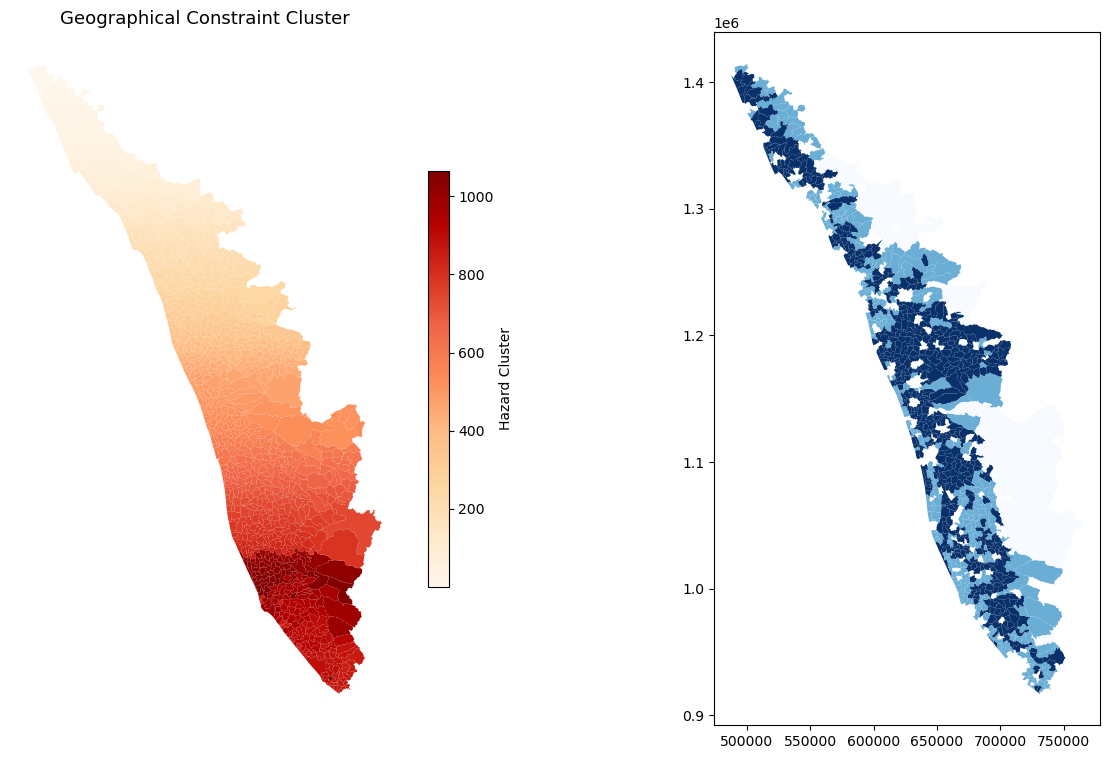

In [43]:
# ── Your GEO file has no cluster number column yet ────────────────────────────
# "Excel_LINK" appears to be the cluster — check unique values
print("Excel_LINK unique values:", geo_gdf["Excel_LINK"].unique())

# If Excel_LINK IS your geo cluster number, map it:
geo_labels = {
    1: "Coastal Erosion & Flood Risk",
    2: "High Flood & Sea-Level Rise",
    3: "CRZ Multi-Hazard",
    4: "Landslide Ecologically Sensitive",
    5: "Moderate Multi-Hazard Inland"
}

combined["geo_label"]     = combined["Excel_LINK"].map(geo_labels)
combined["tod_label"]     = combined["kmeans_lab"]
combined["combined_type"] = combined["geo_label"] + " | " + combined["tod_label"]

print(combined[["Name", "Excel_LINK", "geo_label", "tod_label", "combined_type"]].head(20))

# ── Cross-tabulation ──────────────────────────────────────────────────────────
crosstab = pd.crosstab(combined["geo_label"], combined["tod_label"], margins=True)
print("\n", crosstab)

# ── Export ────────────────────────────────────────────────────────────────────
combined.to_file(r"D:\MPLAN\thesis\combined_clusters.gpkg", driver="GPKG")
combined.drop(columns="geometry").to_csv(r"D:\MPLAN\thesis\combined_clusters.csv", index=False)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

combined.plot(column="Excel_LINK", ax=axes[0], cmap="OrRd", legend=True,
              legend_kwds={"label": "Hazard Cluster", "shrink": 0.6})
axes[0].set_title("Geographical Constraint Cluster", fontsize=13)
axes[0].axis("off")

combined.plot(column="TOD_cluste", ax=axes[1], cmap="Blues", legend=True,
              legend_kwds={"label": "TOD Cluster", "shrink": 0.6})
axes[1].set_title("TOD Suitability Cluster", fontsize=13)
axes[1].axis("off")

plt.suptitle("Kerala Panchayats: Hazard vs TOD Cluster Overlay", fontsize=15)
plt.tight_layout()
plt.savefig(r"D:\MPLAN\thesis\cluster_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

TypeError: Legend.__init__() got an unexpected keyword argument 'shrink'

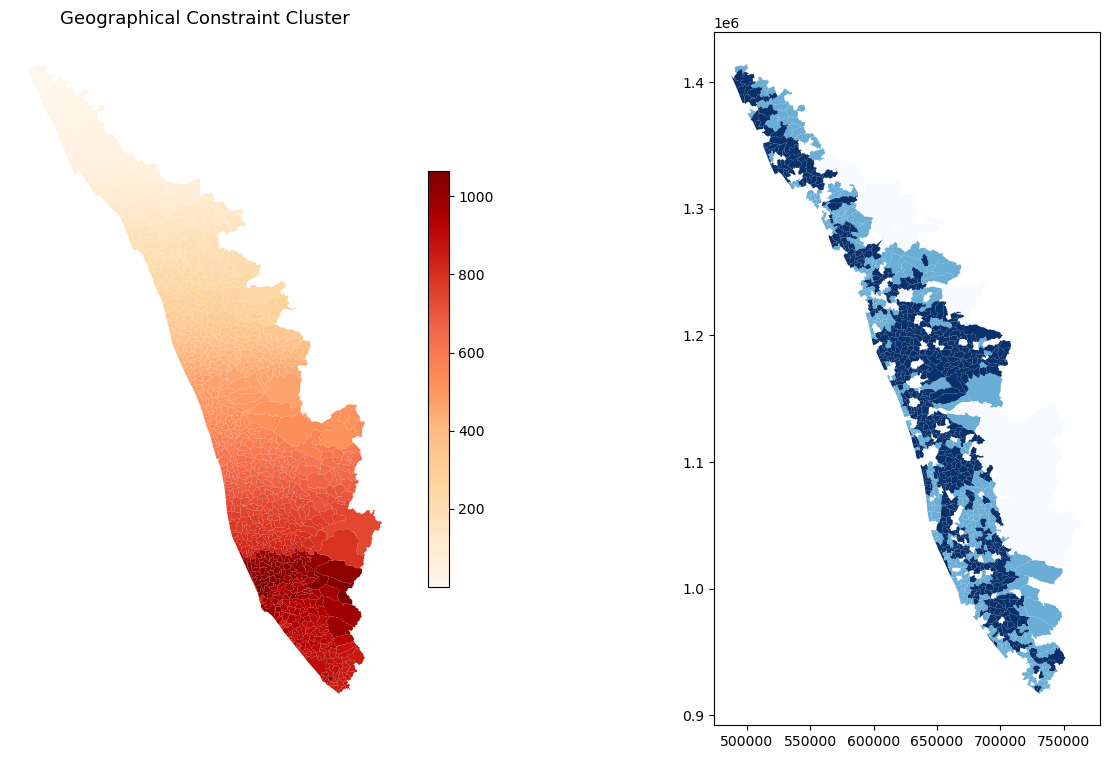

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

combined.plot(
    column="Excel_LINK", ax=axes[0],
    cmap="OrRd", legend=True,
    legend_kwds={"shrink": 0.6}        # ← removed "label" key
)
axes[0].set_title("Geographical Constraint Cluster", fontsize=13)
axes[0].axis("off")

combined.plot(
    column="TOD_cluste", ax=axes[1],
    cmap="Blues", legend=True,
    legend_kwds={"shrink": 0.6}        # ← removed "label" key
)
axes[1].set_title("TOD Suitability Cluster", fontsize=13)
axes[1].axis("off")

# Add manual titles to the colorbars after plotting
axes[0].get_figure().axes[2].set_ylabel("Hazard Cluster", fontsize=10)
axes[1].get_figure().axes[3].set_ylabel("TOD Cluster", fontsize=10)

plt.suptitle("Kerala Panchayats: Hazard vs TOD Cluster Overlay", fontsize=15)
plt.tight_layout()
plt.savefig(r"D:\MPLAN\thesis\cluster_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

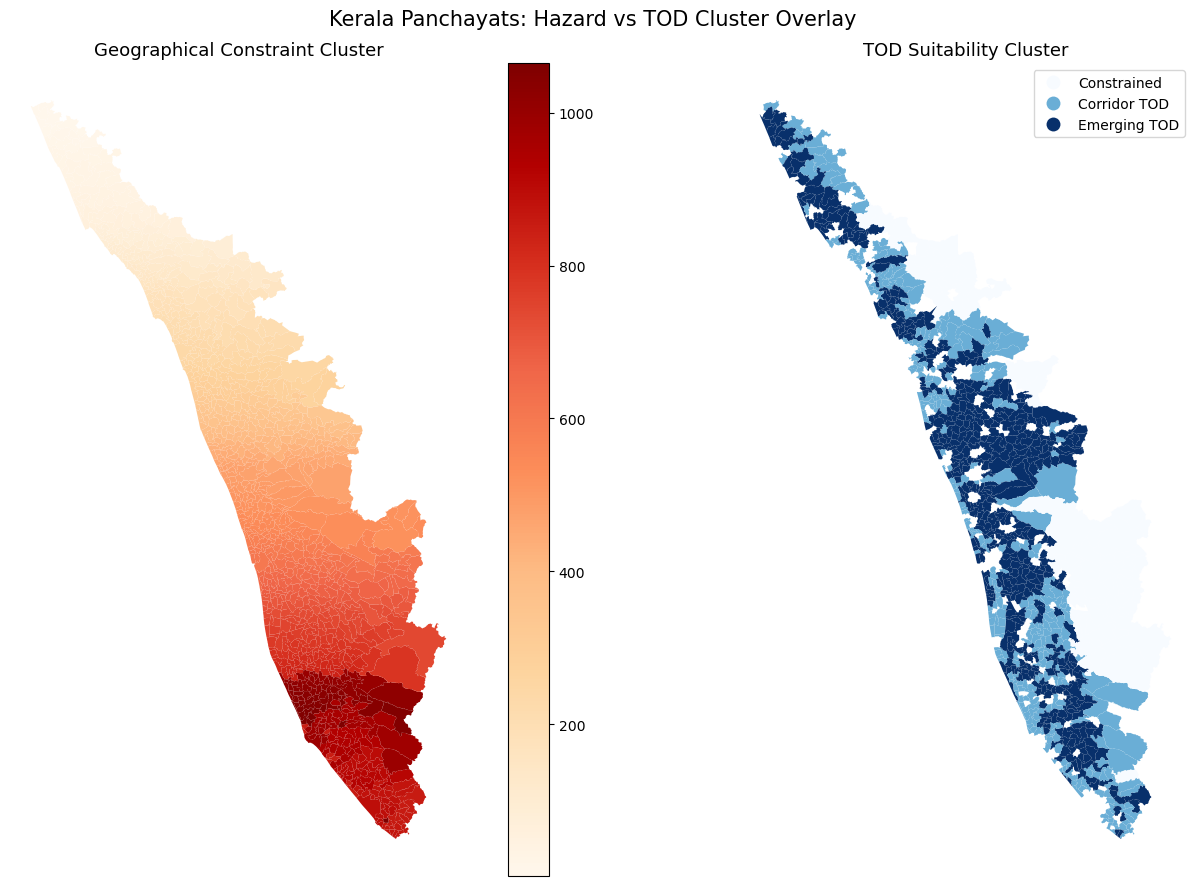

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

combined.plot(
    column="Excel_LINK", ax=axes[0],
    cmap="OrRd", legend=True
)
axes[0].set_title("Geographical Constraint Cluster", fontsize=13)
axes[0].axis("off")

combined.plot(
    column="TOD_cluste", ax=axes[1],
    cmap="Blues", legend=True
)
axes[1].set_title("TOD Suitability Cluster", fontsize=13)
axes[1].axis("off")

plt.suptitle("Kerala Panchayats: Hazard vs TOD Cluster Overlay", fontsize=15)
plt.tight_layout()
plt.savefig(r"D:\MPLAN\thesis\cluster_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

GEO columns: ['FID', 'LSG', 'SLR', 'ESA', '.COA ERO', 'FLOOD', 'LANDSLIDE', 'DROUGHT', 'CRZ', 'Cluster 4', 'Cluster 5', 'Cluster 6', 'Cluster']
TOD columns: ['Name_1', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'TSI_score', 'TSI_class', 'TOD_cluster', 'cluster_id', 'cluster_kmeans', 'kmeans_label', 'cluster_dbscan', 'dbscan_label', 'cluster_skater', 'skater_label']

GEO sample:
    FID                 LSG  SLR  ESA  .COA ERO  FLOOD  LANDSLIDE  DROUGHT  \
0  657  Abdu Rahiman Nagar    2    1         1      3          1        3   
1  966                Adat    3    1         1      4          1        3   
2  435       Adichanalloor    1    1         1      2          1        3   

   CRZ  Cluster 4  Cluster 5  Cluster 6  Cluster  
0    1          4          4          5        2  
1    1          4          4          5        2  
2    4          4          5          6        3  

TOD sample:
                Name_1        I1        I2        I3        I4      I5      I6  \
0  Abdu Rahiman N

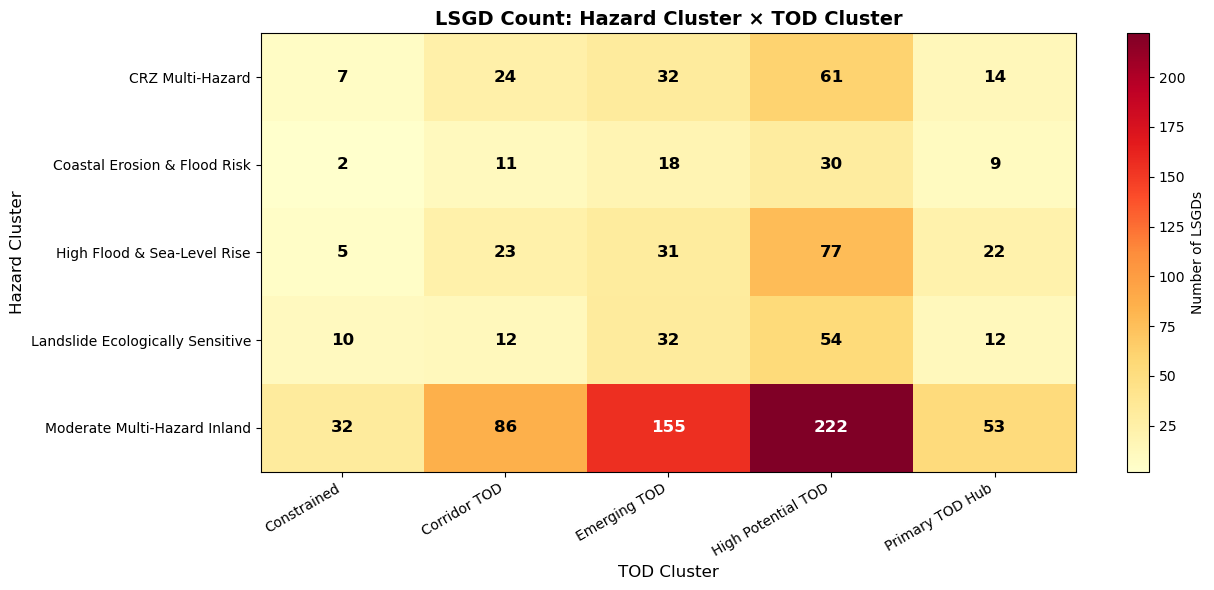

Combined GDF shape: (1057, 10)
Unmatched: 145


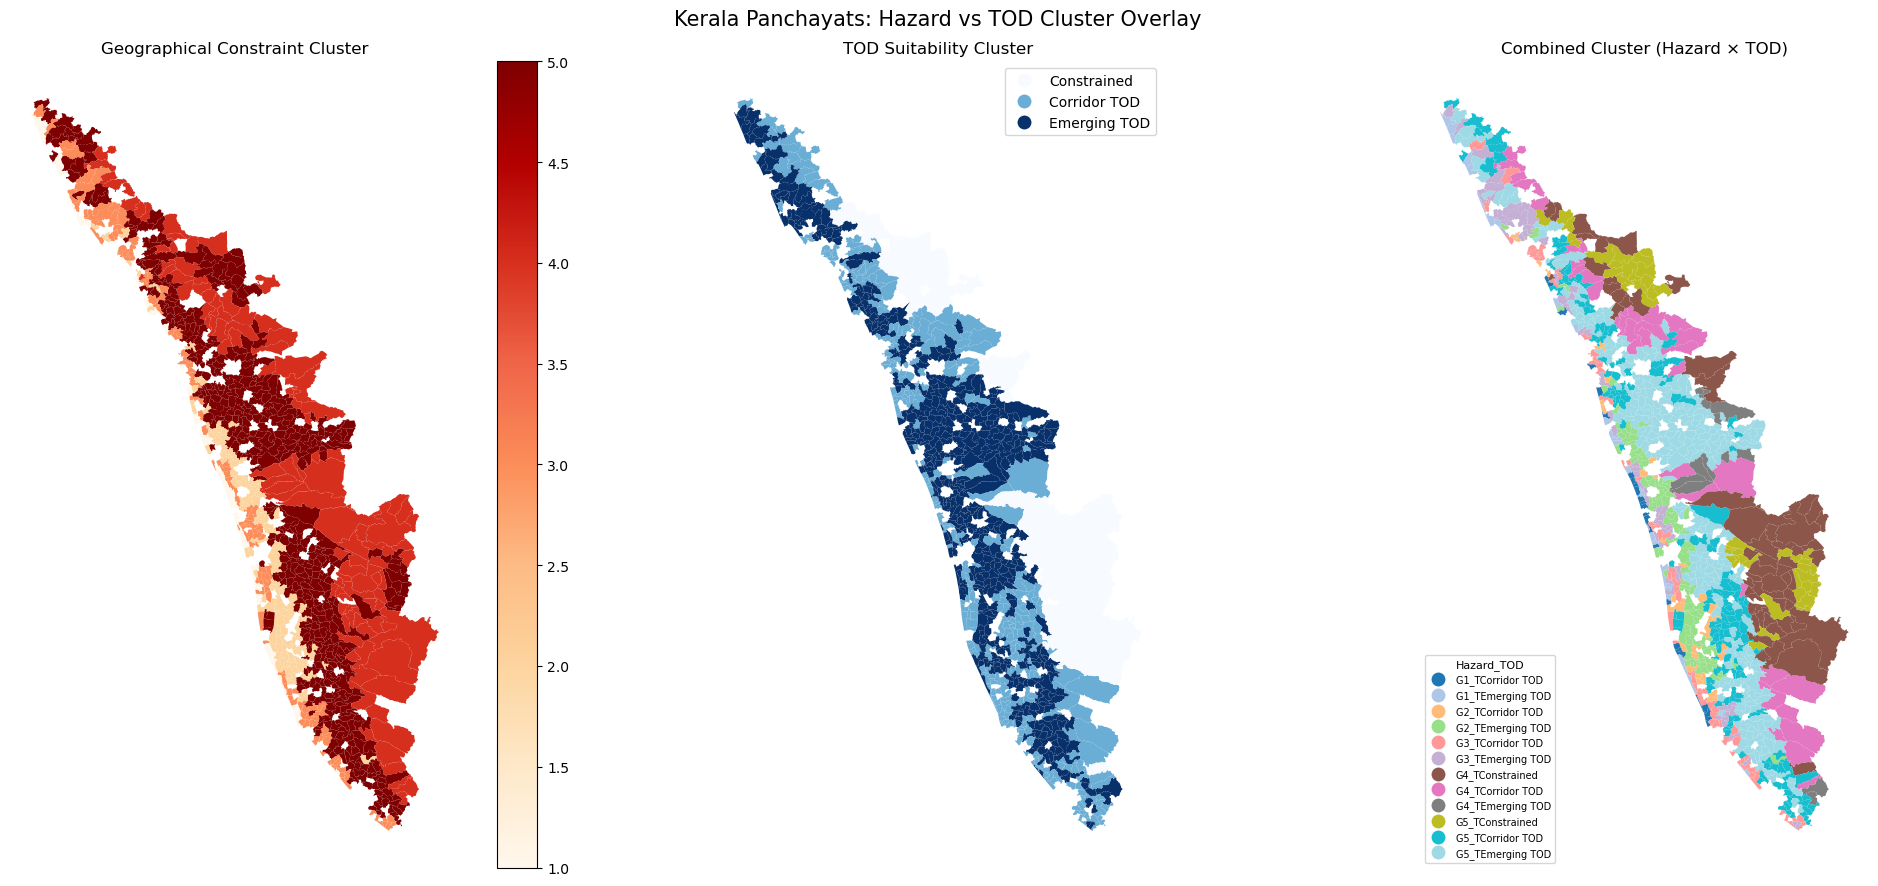

GeoPackage saved.


In [51]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# ── Step 1: Load CSVs ─────────────────────────────────────────────────────────
geo_df = pd.read_csv(r"D:\MPLAN\thesis\cluster_output3.csv",encoding="latin1")
tod_df = pd.read_csv(r"D:\MPLAN\thesis\objective 2\kerala_TSI_all_clusters_clean.csv")

# ── Step 2: Preview ───────────────────────────────────────────────────────────
print("GEO columns:", geo_df.columns.tolist())
print("TOD columns:", tod_df.columns.tolist())
print("\nGEO sample:\n", geo_df.head(3))
print("\nTOD sample:\n", tod_df.head(3))

# ── Step 3: Fix TOD duplicates (Valanchery repeats many times) ────────────────
tod_clean = (
    tod_df
    .sort_values("TSI_score", ascending=False)
    .drop_duplicates(subset="Name_1", keep="first")
)

# ── Step 4: Keep only needed TOD columns ──────────────────────────────────────
tod_cols = ["Name_1", "TSI_score", "TSI_class", "TOD_cluster", "kmeans_label"]

# ── Step 5: Merge — GEO "LSG" matches TOD "Name_1" ───────────────────────────
combined = geo_df.merge(
    tod_clean[tod_cols],
    left_on="LSG",         # ← your geo cluster name column
    right_on="Name_1",     # ← your TOD name column
    how="left"
)

print("\nUnmatched LSGDs:", combined["TOD_cluster"].isna().sum())
print(combined[["LSG", "Cluster", "TOD_cluster", "kmeans_label"]].head(10))

# ── Step 6: Check name mismatches if unmatched > 0 ───────────────────────────
geo_names = set(geo_df["LSG"].dropna())
tod_names = set(tod_clean["Name_1"].dropna())
print("\nIn GEO but not TOD:", geo_names - tod_names)
print("In TOD but not GEO:", tod_names - geo_names)

# ── Step 7: Readable labels ───────────────────────────────────────────────────
# Your geo "Cluster" column has values 1–5
geo_labels = {
    1: "Coastal Erosion & Flood Risk",
    2: "High Flood & Sea-Level Rise",
    3: "CRZ Multi-Hazard",
    4: "Landslide Ecologically Sensitive",
    5: "Moderate Multi-Hazard Inland"
}

# TOD kmeans_lab already has readable labels:
# "Primary TOD Hub", "High Potential TOD",
# "Corridor TOD", "Emerging TOD", "Constrained"

combined["geo_label"]      = combined["Cluster"].map(geo_labels)
combined["tod_label"]      = combined["kmeans_label"]
combined["combined_code"]  = (
    "G" + combined["Cluster"].astype(str) +
    "_T" + combined["TOD_cluster"].astype(str)
)
combined["combined_label"] = combined["geo_label"] + " | " + combined["tod_label"]

# ── Step 8: Full preview ──────────────────────────────────────────────────────
print("\n── Each LSGD with combined cluster ──")
print(combined[["LSG", "Cluster", "geo_label",
                "TOD_cluster", "tod_label",
                "combined_code", "combined_label"]].to_string(index=False))

# ── Step 9: Cross-tabulation ──────────────────────────────────────────────────
crosstab = pd.crosstab(
    combined["geo_label"],
    combined["tod_label"],
    margins=True,
    margins_name="Total"
)
print("\n── Cross-tabulation (number of LSGDs per combination) ──")
print(crosstab.to_string())

# ── Step 10: Summary table ────────────────────────────────────────────────────
summary = combined[[
    "LSG", "FID", "Cluster", "geo_label",
    "TOD_cluster", "tod_label",
    "combined_code", "combined_label",
    "TSI_score", "TSI_class",
    "SLR", "ESA", "FLOOD", "LANDSLIDE", "DROUGHT", "CRZ"
]].copy()

summary.columns = [
    "LSGD", "FID", "Hazard_Cluster_No", "Hazard_Label",
    "TOD_Cluster_No", "TOD_Label",
    "Combined_Code", "Combined_Label",
    "TSI_Score", "TSI_Class",
    "SLR", "ESA", "Flood", "Landslide", "Drought", "CRZ"
]
summary = summary.sort_values(["Hazard_Cluster_No", "TOD_Cluster_No"])

print("\n── Summary table ──")
print(summary.to_string(index=False))

# ── Step 11: Export CSVs ──────────────────────────────────────────────────────
combined.to_csv(r"D:\MPLAN\thesis\objective 2\combined_clusters_full.csv", index=False)
summary.to_csv(r"D:\MPLAN\thesis\objective 2\combined_clusters_summary.csv", index=False)
print("\nCSVs saved.")

# ── Step 12: Heatmap ──────────────────────────────────────────────────────────
crosstab_data = pd.crosstab(combined["geo_label"], combined["tod_label"])

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(crosstab_data.values, cmap="YlOrRd", aspect="auto")
plt.colorbar(im, ax=ax, label="Number of LSGDs")

ax.set_xticks(range(len(crosstab_data.columns)))
ax.set_xticklabels(crosstab_data.columns, rotation=30, ha="right", fontsize=10)
ax.set_yticks(range(len(crosstab_data.index)))
ax.set_yticklabels(crosstab_data.index, fontsize=10)

for i in range(len(crosstab_data.index)):
    for j in range(len(crosstab_data.columns)):
        val = crosstab_data.values[i, j]
        ax.text(j, i, str(val), ha="center", va="center",
                fontsize=12, fontweight="bold",
                color="black" if val < crosstab_data.values.max() * 0.6 else "white")

ax.set_title("LSGD Count: Hazard Cluster × TOD Cluster",
             fontsize=14, fontweight="bold")
ax.set_xlabel("TOD Cluster", fontsize=12)
ax.set_ylabel("Hazard Cluster", fontsize=12)
plt.tight_layout()
plt.savefig(r"D:\MPLAN\thesis\objective 2\cluster_matrix_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Step 13: Map (shapefile only for visualization) ───────────────────────────
# CORRECTED PATH — same location as your original load
geo_shp = gpd.read_file(
    r"D:\MPLAN\thesis\geographic constraints\data\cluster_of_4.shp"
)

# Attach combined result back to shapefile
combined_gdf = geo_shp.merge(
    combined[["LSG", "Cluster", "geo_label",
              "TOD_cluster", "tod_label",
              "combined_code", "combined_label"]],
    left_on="Name",
    right_on="LSG",
    how="left"
)

print("Combined GDF shape:", combined_gdf.shape)
print("Unmatched:", combined_gdf["TOD_cluster"].isna().sum())

fig, axes = plt.subplots(1, 3, figsize=(22, 9))

combined_gdf.plot(column="Cluster", ax=axes[0],
                  cmap="OrRd", legend=True)
axes[0].set_title("Geographical Constraint Cluster", fontsize=12)
axes[0].axis("off")

combined_gdf.plot(column="TOD_cluster", ax=axes[1],
                  cmap="Blues", legend=True)
axes[1].set_title("TOD Suitability Cluster", fontsize=12)
axes[1].axis("off")

combined_gdf.plot(column="combined_code", ax=axes[2],
                  cmap="tab20", legend=True,
                  legend_kwds={"loc": "lower left",
                               "fontsize": 7,
                               "title": "Hazard_TOD",
                               "title_fontsize": 8})
axes[2].set_title("Combined Cluster (Hazard × TOD)", fontsize=12)
axes[2].axis("off")

plt.suptitle("Kerala Panchayats: Hazard vs TOD Cluster Overlay", fontsize=15)
plt.tight_layout()
plt.savefig(r"D:\MPLAN\thesis\cluster_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

combined_gdf.to_file(r"D:\MPLAN\thesis\combined_clusters.gpkg", driver="GPKG")
print("GeoPackage saved.")

In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples

combined = pd.read_csv(r"D:\MPLAN\thesis\objective 2\combined_clusters_full.csv")

feature_cols = ["SLR", "ESA", "FLOOD", "LANDSLIDE", "DROUGHT", "CRZ", "TSI_score"]

check_df = combined.dropna(subset=feature_cols + ["combined_code"]).copy()
X_scaled = StandardScaler().fit_transform(check_df[feature_cols].values)
labels = check_df["combined_code"].values

overall_sil = silhouette_score(X_scaled, labels)
print(f"Overall silhouette score for combined_code: {overall_sil:.3f}")

check_df["sil"] = silhouette_samples(X_scaled, labels)
per_cluster = (
    check_df.groupby("combined_code")["sil"]
    .agg(["mean", "count"])
    .sort_values("mean")
)
print(per_cluster.round(3).to_string())

Overall silhouette score for combined_code: -0.017
                   mean  count
combined_code                 
G1_TCorridor TOD -0.164     34
G2_TCorridor TOD -0.153     51
G5_TCorridor TOD -0.143    186
G4_TCorridor TOD -0.138     40
G4_TConstrained  -0.123     65
G1_TEmerging TOD -0.116     36
G3_TEmerging TOD -0.073     66
G5_TEmerging TOD  0.033    316
G3_TCorridor TOD  0.053     72
G5_TConstrained   0.119     46
G4_TEmerging TOD  0.130     15
G2_TEmerging TOD  0.222    107


C:\Users\DEVANSHI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\DEVANSHI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\DEVANSHI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\DEVANSHI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory le

── Cluster validity metrics by k ──
 k  silhouette  calinski_harabasz  davies_bouldin  inertia
 2       0.249            319.939           1.541 5525.112
 3       0.286            333.371           1.388 4395.474
 4       0.331            332.953           1.166 3674.550
 5       0.317            345.640           1.130 3088.415
 6       0.327            345.830           1.054 2698.678
 7       0.312            336.610           1.035 2439.863
 8       0.307            321.316           1.059 2267.392
 9       0.319            310.912           1.090 2112.277
10       0.330            301.029           1.123 1985.316

Highest silhouette score at k = 4 (silhouette = 0.331)
Compare against the Calinski-Harabasz peak and Davies-Bouldin trough below before finalizing k — pick the value where the metrics broadly agree, not just the single highest silhouette score.


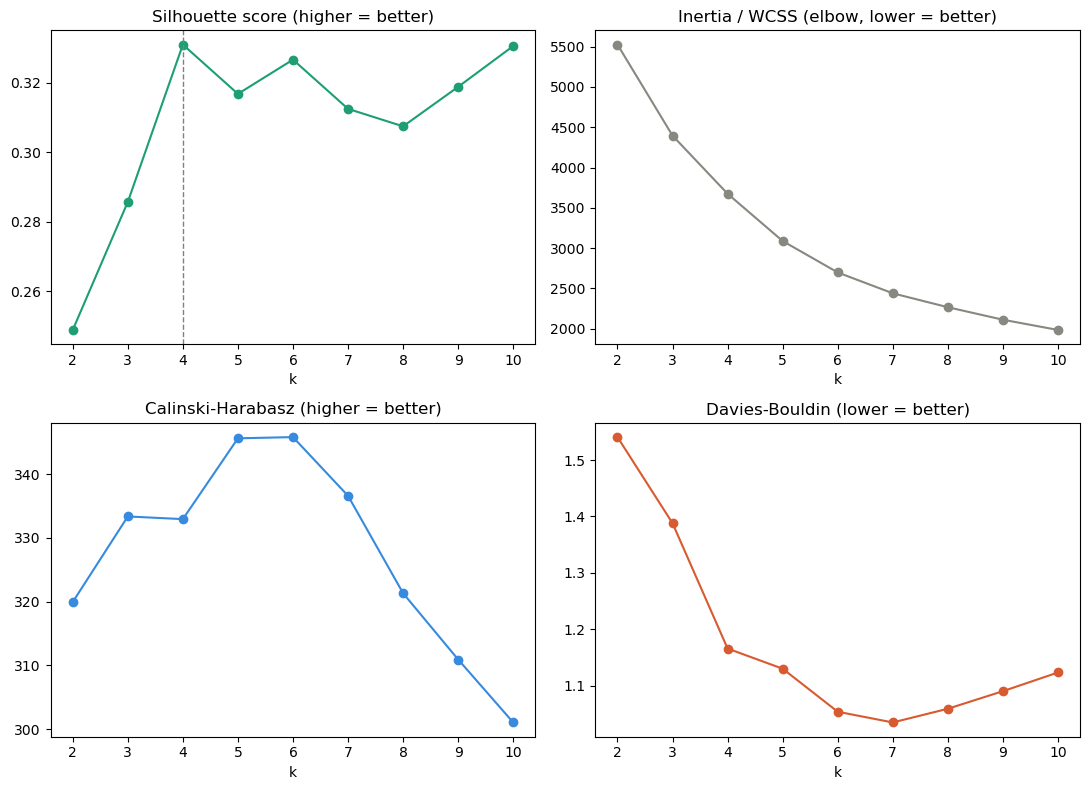


── Final cluster feature centers (original scale) ──
     SLR    ESA  Flood  Landslide  Drought    CRZ  TSI_Score  count
0  1.420  1.013  2.707      1.113    2.820  3.667      0.092    150
1  1.053  1.049  2.176      1.374    2.637  1.086      0.089    567
2  2.330  1.000  3.367      1.011    2.819  1.197      0.122    188
3  1.000  2.806  1.682      2.845    2.372  1.000      0.049    129

── Auto-generated cluster labels ──
  Cluster 0 (n=150): CRZ-Dominant Hazard, Moderate TOD Potential
  Cluster 1 (n=567): Moderate Mixed Hazard, Moderate TOD Potential
  Cluster 2 (n=188): Sea-Level Rise-Dominant Hazard, Exceptional TOD Potential
  Cluster 3 (n=129): Ecologically Sensitive Area-Dominant Hazard, Limited TOD Potential

Saved: D:\MPLAN\research paper\combined_clusters_final_kmeans.csv
Saved: D:\MPLAN\research paper\cluster_validity_metrics.png


C:\Users\DEVANSHI\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# ── Step 0: Config ────────────────────────────────────────────────────────────
INPUT_CSV   = r"D:\MPLAN\thesis\objective 2\combined_clusters_summary.csv"
OUTPUT_CSV  = r"D:\MPLAN\research paper\combined_clusters_final_kmeans.csv"
OUTPUT_PLOT = r"D:\MPLAN\research paper\cluster_validity_metrics.png"
K_RANGE     = range(2, 11)

HAZARD_COLS = ["SLR", "ESA", "Flood", "Landslide", "Drought", "CRZ"]
TOD_COL     = "TSI_Score"
FEATURE_COLS = HAZARD_COLS + [TOD_COL]

# ── Step 1: Load data and build the feature matrix ───────────────────────────
df = pd.read_csv(INPUT_CSV)
X = df[FEATURE_COLS].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Step 2: Scan k and compute validity metrics ───────────────────────────────
records = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    records.append({
        "k": k,
        "silhouette": silhouette_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels),
        "inertia": km.inertia_,
    })

metrics_df = pd.DataFrame(records)
print("── Cluster validity metrics by k ──")
print(metrics_df.round(3).to_string(index=False))

best_k_silhouette = int(metrics_df.loc[metrics_df["silhouette"].idxmax(), "k"])
print(f"\nHighest silhouette score at k = {best_k_silhouette} "
      f"(silhouette = {metrics_df['silhouette'].max():.3f})")
print("Compare against the Calinski-Harabasz peak and Davies-Bouldin trough below "
      "before finalizing k — pick the value where the metrics broadly agree, "
      "not just the single highest silhouette score.")

# ── Step 3: Plot all four metrics vs k ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].plot(metrics_df["k"], metrics_df["silhouette"], "o-", color="#1D9E75")
axes[0, 0].set_title("Silhouette score (higher = better)")
axes[0, 0].set_xlabel("k")
axes[0, 0].axvline(best_k_silhouette, color="gray", linestyle="--", linewidth=1)

axes[0, 1].plot(metrics_df["k"], metrics_df["inertia"], "o-", color="#888780")
axes[0, 1].set_title("Inertia / WCSS (elbow, lower = better)")
axes[0, 1].set_xlabel("k")

axes[1, 0].plot(metrics_df["k"], metrics_df["calinski_harabasz"], "o-", color="#378ADD")
axes[1, 0].set_title("Calinski-Harabasz (higher = better)")
axes[1, 0].set_xlabel("k")

axes[1, 1].plot(metrics_df["k"], metrics_df["davies_bouldin"], "o-", color="#D85A30")
axes[1, 1].set_title("Davies-Bouldin (lower = better)")
axes[1, 1].set_xlabel("k")

plt.tight_layout()
plt.savefig(OUTPUT_PLOT, dpi=150, bbox_inches="tight")
plt.show()

# ── Step 4: Re-fit KMeans at your chosen k ────────────────────────────────────
# Review metrics_df and the plot above, then set FINAL_K explicitly.
# Defaulting to the silhouette-best k found above — override if the other
# metrics point elsewhere.
FINAL_K = best_k_silhouette

km_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
df["Final_Cluster_No"] = km_final.fit_predict(X_scaled)

# ── Step 5: Auto-label clusters from their feature centers ──────────────────
# Standardized centers tell us, per cluster, which features sit above/below
# the dataset average (z > 0 = above average for that feature).
centers_scaled = km_final.cluster_centers_                     # standardized
centers_original = scaler.inverse_transform(centers_scaled)    # original units
centers_df = pd.DataFrame(centers_original, columns=FEATURE_COLS)
centers_df["count"] = pd.Series(df["Final_Cluster_No"]).value_counts().sort_index().values

print("\n── Final cluster feature centers (original scale) ──")
print(centers_df.round(3).to_string())

HAZARD_NAME_MAP = {
    "SLR": "Sea-Level Rise",
    "ESA": "Ecologically Sensitive Area",
    "Flood": "Flood",
    "Landslide": "Landslide",
    "Drought": "Drought",
    "CRZ": "CRZ",
}
HAZARD_IDX = [FEATURE_COLS.index(c) for c in HAZARD_COLS]
TOD_IDX = FEATURE_COLS.index(TOD_COL)

def label_cluster(z_row, hazard_threshold=0.4, tod_high=0.5, tod_low=-0.3):
    """Build an interpretable label from a cluster's standardized center."""
    hazard_z = z_row[HAZARD_IDX]
    tod_z = z_row[TOD_IDX]

    dominant_idx = np.argmax(hazard_z)
    dominant_z = hazard_z[dominant_idx]
    if dominant_z >= hazard_threshold:
        hazard_part = f"{HAZARD_NAME_MAP[HAZARD_COLS[dominant_idx]]}-Dominant Hazard"
    elif np.mean(hazard_z) <= -hazard_threshold:
        hazard_part = "Low Overall Hazard"
    else:
        hazard_part = "Moderate Mixed Hazard"

    if tod_z >= tod_high:
        tod_part = "Exceptional TOD Potential"
    elif tod_z >= tod_low:
        tod_part = "Moderate TOD Potential"
    else:
        tod_part = "Limited TOD Potential"

    return f"{hazard_part}, {tod_part}"

cluster_labels = {i: label_cluster(centers_scaled[i]) for i in range(FINAL_K)}
df["Final_Cluster_Label"] = df["Final_Cluster_No"].map(cluster_labels)

print("\n── Auto-generated cluster labels ──")
for i, lab in cluster_labels.items():
    n = (df["Final_Cluster_No"] == i).sum()
    print(f"  Cluster {i} (n={n}): {lab}")

# ── Step 6: Export ────────────────────────────────────────────────────────────
df.to_csv(OUTPUT_CSV, index=False)
print(f"\nSaved: {OUTPUT_CSV}")
print(f"Saved: {OUTPUT_PLOT}")

Merged shape: (1057, 5)
Unmatched: 145


C:\Users\DEVANSHI\AppData\Local\Temp\ipykernel_8388\2707057978.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10" if n_categories <= 10 else "tab20", n_categories)


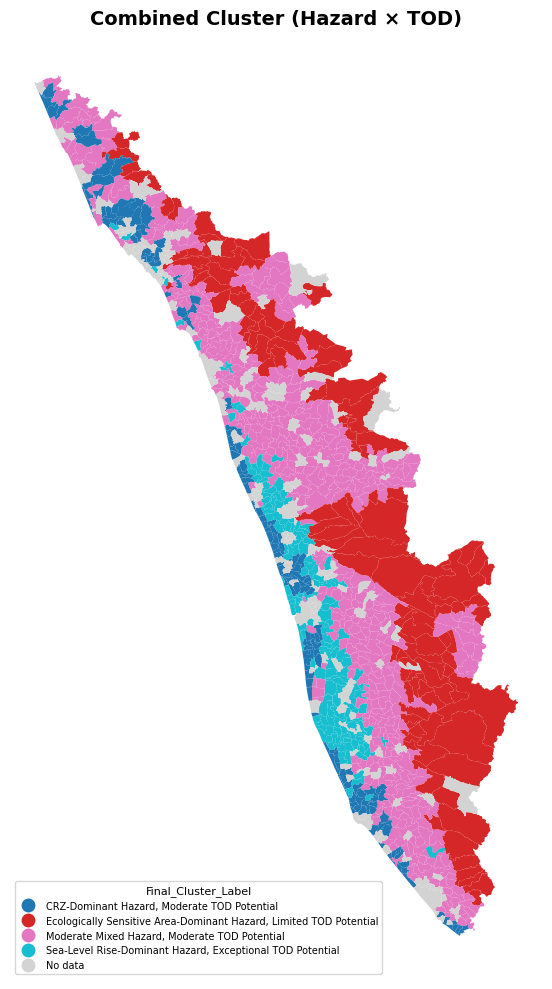

In [6]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ── Load shapefiles ───────────────────────────────────────────────────────────
geo_gdf = gpd.read_file(r"D:\MPLAN\thesis\geographic constraints\data\cluster_of_4.shp")
tod_gdf = gpd.read_file(r"D:\MPLAN\thesis\objective 2\final_TOD_cluster.shp")

# ── Step 2: Load whichever clustering CSV you want to map ────────────────────
# Swap this for combined_clusters_full.csv, combined_clusters_final_kmeans.csv,
# or combined_clusters_reduced.csv depending on which result you're mapping.
clusters_df = pd.read_csv(r"D:\MPLAN\research paper\datafiles\combined_clusters_final_kmeans.csv")

# ── Step 3: Set which column to color the map by ──────────────────────────────
COLUMN_TO_MAP = "Final_Cluster_Label"   # ← change this to whatever column you want
NAME_COL_IN_CSV = "LSGD"                # ← the LSGD name column in clusters_df

# ── Step 4: Merge onto the shapefile ──────────────────────────────────────────
merged = geo_gdf.merge(
    clusters_df[[NAME_COL_IN_CSV, COLUMN_TO_MAP]],
    left_on="Name",
    right_on=NAME_COL_IN_CSV,
    how="left"
)
print("Merged shape:", merged.shape)
print("Unmatched:", merged[COLUMN_TO_MAP].isna().sum())

# ── Step 5: Plot ──────────────────────────────────────────────────────────────
n_categories = merged[COLUMN_TO_MAP].nunique()
cmap = cm.get_cmap("tab10" if n_categories <= 10 else "tab20", n_categories)

fig, ax = plt.subplots(figsize=(8, 10))
merged.plot(
    column=COLUMN_TO_MAP,
    ax=ax,
    cmap=cmap,
    legend=True,
    legend_kwds={
        "loc": "lower left",
        "fontsize": 7,
        "title": COLUMN_TO_MAP,
        "title_fontsize": 8
    },
    missing_kwds={"color": "lightgrey", "label": "No data"}
)
ax.set_title("Combined Cluster (Hazard × TOD)", fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig(r"D:\MPLAN\research paper\final_cluster_map.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# ── Step 6: Export shapefile ──────────────────────────────────────────────────
# Shapefile truncates column names to 10 chars — rename first to avoid silent collisions
export_gdf = merged.rename(columns={COLUMN_TO_MAP: "ClustLabel"})

export_gdf.to_file(
    r"D:\MPLAN\research paper\final_cluster_map.shp",
    driver="ESRI Shapefile"
)
print("Shapefile saved.")

Shapefile saved.


In [8]:
# ── See exactly which names failed to match ───────────────────────────────────
unmatched = merged.loc[merged[COLUMN_TO_MAP].isna(), "Name"].dropna().unique()
print(f"{len(unmatched)} unmatched shapefile names:")
print(sorted(unmatched))

# ── Compare the two full name sets directly ───────────────────────────────────
geo_names = set(geo_gdf["Name"].astype(str).str.strip())
csv_names = set(clusters_df["LSGD"].astype(str).str.strip())

print("\nIn shapefile but not in CSV:", sorted(geo_names - csv_names))
print("\nIn CSV but not in shapefile:", sorted(csv_names - geo_names))

143 unmatched shapefile names:
['Adoor (M)', 'Alacode-Idukki', 'Alakode-Kannur', 'Alappuzha (M + OG)', 'Aluva (M)', 'Ancharakandy', 'Angamaly (M)', 'Aryankavu', 'Attingal (M)', 'Beypore', 'Chalakudy (M)', 'Chammanad', 'Changanassery (M)', 'Chavakkad (M)', 'Chekkode-Malappuram', 'Chelora', 'Chengannur (M)', 'Cherpulacherry', 'Cherthala (M)', 'Cheruvannur- Nallalam', 'Chittur-Thathamangalam (M)', 'Chokkade-Nilambur', 'Dharmadom', 'Edakkad', 'Elathur', 'Elayavoor', 'Guruvayoor (M)', 'Irinjalakuda (M)', 'Kadappuram', 'Kadirur', 'Kalady-Ernakulam', 'Kalamassery (M)', 'Kallara-Kottayam', 'Kalliasseri', 'Kalpetta (M)', 'Kanhangad (M + OG)', 'Kanjiramkulam', 'Kannapuram', 'Kannur (M)', 'Karalam', 'Kasaragod (M)', 'Kayamkulam (M)', 'Kazhakkoottam', 'Keezhparamb', 'Keezhur-Chavassery', 'Kelakam', 'Kochi (M Corp.)', 'Kodungallur (M + OG)', 'Kollam (M Corp. + OG)', 'Koothuparamba (M)', 'Kothamangalam (M)', 'Kottappadi', 'Kottarakkara (CT)', 'Kottayam (M)', 'Kottayam-Thalassery', 'Kozhikode (M Corp

In [9]:
import re
import difflib

# ── Step A: Safe automated fix — strip municipal/corp/CT tags only ───────────
SUFFIX_PATTERN = re.compile(
    r"\s*\((m\s*\+?\s*og|m\s*corp\.?\s*\+?\s*og|m\s*corp\.?|m|ct)\)\s*$",
    re.IGNORECASE
)

def strip_admin_tag(name):
    name = str(name).strip()
    name = SUFFIX_PATTERN.sub("", name)
    name = name.replace("MCP", "").strip()
    return re.sub(r"\s+", " ", name)

geo_gdf["Name_clean"] = geo_gdf["Name"].apply(strip_admin_tag)
clusters_df["LSGD_clean"] = clusters_df["LSGD"].astype(str).str.strip()

# Match case-insensitively on the cleaned name
geo_gdf["Name_key"] = geo_gdf["Name_clean"].str.lower()
clusters_df["LSGD_key"] = clusters_df["LSGD_clean"].str.lower()

merged = geo_gdf.merge(
    clusters_df[["LSGD_key", COLUMN_TO_MAP]],
    left_on="Name_key",
    right_on="LSGD_key",
    how="left"
)
print("Unmatched after Step A (admin-tag strip):", merged[COLUMN_TO_MAP].isna().sum())

# ── Step B: Fuzzy-match review list for everything still unmatched ───────────
# This does NOT auto-apply anything — it just suggests candidates for YOU to confirm.
still_unmatched = sorted(
    geo_gdf.loc[~geo_gdf["Name_key"].isin(clusters_df["LSGD_key"]), "Name_key"].dropna().unique()
)
csv_pool = clusters_df["LSGD_key"].unique().tolist()

print(f"\n{len(still_unmatched)} names still need manual review:\n")
for name in still_unmatched:
    candidates = difflib.get_close_matches(name, csv_pool, n=2, cutoff=0.55)
    print(f"  shapefile: {name!r:35s} → candidates: {candidates}")

Unmatched after Step A (admin-tag strip): 82

81 names still need manual review:

  shapefile: 'alacode-idukki'                    → candidates: ['alacode', 'alamcode']
  shapefile: 'alakode-kannur'                    → candidates: ['valavannur', 'alakode']
  shapefile: 'aryankavu'                         → candidates: ['arienkavu', 'bharanikkavu']
  shapefile: 'beypore'                           → candidates: ['edayoor']
  shapefile: 'chammanad'                         → candidates: ['chengamanad', 'chemnad']
  shapefile: 'chekkode-malappuram'               → candidates: ['malappuram', 'chennam-pallippuram']
  shapefile: 'chelora'                           → candidates: ['chelambra', 'chelakkara']
  shapefile: 'cherpulacherry'                    → candidates: ['cherpulassery', 'kolacherry']
  shapefile: 'cheruvannur- nallalam'             → candidates: ['cheruvannur', 'thiruvananthapuram']
  shapefile: 'chokkade-nilambur'                 → candidates: ['nilambur', 'kadambur']
  shapef

In [10]:
import difflib

print(f"{'shapefile name':30s} {'best candidate':30s} {'score':>6s}")
for name in still_unmatched:
    matches = difflib.get_close_matches(name, csv_pool, n=1, cutoff=0.0)
    if matches:
        score = difflib.SequenceMatcher(None, name, matches[0]).ratio()
        flag = "" if score >= 0.72 else "  ← low confidence, verify manually"
        print(f"{name:30s} {matches[0]:30s} {score:6.2f}{flag}")
    else:
        print(f"{name:30s} {'(no candidate)':30s} {'--':>6s}")

shapefile name                 best candidate                  score
alacode-idukki                 alacode                          0.67  ← low confidence, verify manually
alakode-kannur                 valavannur                       0.67  ← low confidence, verify manually
aryankavu                      arienkavu                        0.78
beypore                        edayoor                          0.57  ← low confidence, verify manually
chammanad                      chengamanad                      0.80
chekkode-malappuram            malappuram                       0.69  ← low confidence, verify manually
chelora                        chelambra                        0.75
cherpulacherry                 cherpulassery                    0.81
cheruvannur- nallalam          cheruvannur                      0.69  ← low confidence, verify manually
chokkade-nilambur              nilambur                         0.64  ← low confidence, verify manually
edakkad                        

In [15]:
# ── Administrative absorptions: locality now part of a larger Corporation/Municipality ──
# These are NOT typos — verified real boundary mergers. Document the source if you can
# (e.g. LSGD Dept notification, Census handbook) since this affects your unit of analysis.
corporation_absorptions = {
    "beypore": "kozhikode",
    "chelora" : "Kannur"  ,  
    "cheruvannur- nallalam" : "kozhikode",  
    "edakkad": "kozhikode", 
    "elathur": "kozhikode",
   "elayavoor" : "Kannur", 
    "kazhakkoottam": "Thiruvananthapuram",
    "kudappanakunnu": "Thiruvananthapuram",
    "kumaranalloor" :  "kottayam" ,
    "methala" : "Kodungallur",
    "nattakam" : "kottayam"  ,
    "sreekaryam" : "Thiruvananthapuram",
}

# ── Spelling/transliteration variants (verified, not absorptions) ────────────
manual_overrides = {
"alacode-idukki"    :"alacode",                         
"alakode-kannur"    :"alakode",                      
"aryankavu"          : "arienkavu",                                                 
"chammanad"          : "chengamanad",                      
"chekkode-malappuram" :"Cheacode" ,                                          
"cherpulacherry":   "cherpulassery" ,                                         
"chokkade-nilambur" :  "chokkad",                                                                                          
"guruvayoor"    :   "guruvayur"  ,                      
"kalady-ernakulam" : "kalady"   ,                    
"kallara-kottayam" : "kallara",                                      
"keezhparamb" :      "kizhuparamba" ,                    
"keezhur-chavassery": "keezhur-chavassery" ,                   
"kelakam"  : "kelakam" ,                   
"koothuparamba":               "koothuparambu" ,                   
"kottappadi" :                  "kottappady"    ,                   
"kottarakkara"   :                "kottarakara"   ,                   
"kottayam-thalassery" :            "thalassery"    ,                                  
"kulanada-pathanamthitta"  : "kulanada"      ,                            
"kurachundu"  :                   "koorachundu"    ,                  
"madavoor-tvm" :                   "madavoor"       ,                  
"manjeshwaram-ksgd"  :            "manjeshwar"    ,                   
"mannarkad"          :            "mannarkkad"     ,                  
"mattannur"           :           "mattanur"       ,                                
"mukkom"   :   "mukkam"  ,                  
"mundathikode"  :   "mundathicode",                  
"muttar-alappuzha": "Muttar" ,                  
"nediyiruppu" :  "nediyiruppu" ,                 
"nedumpuram-pathanamthitta" :  "nedumpuram"     ,                 
"neelemperoor-alappuzha"   : "neelamperoor"     ,                
"nileshwar "               : "nileshwaram"      ,                               
"north paravoor" :         "north paravur"    ,              
"ochira"         :                "oachira"  ,               
"palai" :                          "pala"   ,              
"pallikal-kondotty" :             "pallikal",              
"pallikkal"          :            "pallikal" ,            
"pallikkunnu" :                    "pallikkunnu",               
"parali" :                        "parlai" ,             
"parappanagadi" :                 "parappanangadi"    ,               
"paravur" :                        "paravoor"  ,              
"pariyaram-thrissur" :             "pariyaram"         ,               
"payyannur" :                      "payyanur"          ,              
"peringalam" :                     "peringamala"       ,               
"pookode" :                        "Pattiam",               
"porathissery" :                 "Irinjalakuda"          ,              
"pothakkulam" :                  "poothakkulam"      ,               
"puthussery"    :                 "pudussery"         ,              
"puzhathi"   :                    "puzhakkatiri"      ,              
"quilandy" :                       "koyilandy"         ,              
"sholayar" :                       "sholayur"           ,              
"shoranur" :                       "shornur"            ,                         
"sreenarayanapuram" :              "sreenarayanapuram"    ,              
"sulthan bathery" :               "sultan bathery"     ,             
"taliparamba"     :           "thalipparamba"            ,              
"thaikkad" :                   "Guruvayur"        ,             
"thalakkad" :                   "talakkad"           ,              
"theekoyi" :                     "teekoy"             ,             
"thiruvankulam" :               "Thripunithura"          ,              
"thrikkadavoor"  :                "thrikkadavoor"          ,            
"thrikkakara"    :                "thrikkakkara"       ,             
"thrikkalangode" :             "trikkalangode"      ,              
"thuravoor-ekm"  :             "thuravoor"          ,              
"thuvvur" :                    "thuravoor"            ,             
"urakam" :                      "oorakam"         ,              
"vadakara" :                      "vatakara"           ,              
"vadakkancherry" :             "vadakkancheri"       ,            
"vallikkunnu-malappuram" :      "vallikunnam"        ,             
"vattiyoorkavu"  :                "Thiruvananthapuram"           ,             
"vizhinjam" :               "Thiruvananthapuram"           ,            


}

all_overrides = {**manual_overrides, **corporation_absorptions}

geo_gdf["Name_final"] = geo_gdf["Name_key"].replace(all_overrides)

merged = geo_gdf.merge(
    clusters_df[["LSGD_key", COLUMN_TO_MAP]],
    left_on="Name_final",
    right_on="LSGD_key",
    how="left"
)
print("Unmatched after all overrides:", merged[COLUMN_TO_MAP].isna().sum())

Unmatched after all overrides: 25


In [17]:
still_unmatched_final = merged.loc[merged[COLUMN_TO_MAP].isna(), "Name"].dropna().unique()
print(still_unmatched_final)

['Pookode' 'Nileshwar' 'Chelora' 'Porathissery' 'Kelakam'
 'Taliparamba (M)' 'Keezhur-Chavassery' 'Pallikkunnu' 'Methala'
 'Elayavoor' 'Nediyiruppu' 'Mundathikode' 'Vattiyoorkavu' 'Thaikkad'
 'Thiruvankulam' 'Chekkode-Malappuram' 'Sreenarayanapuram' 'Vizhinjam'
 'Kudappanakunnu' 'Thrikkadavoor' 'Muttar-Alappuzha' 'Sreekaryam'
 'Kazhakkoottam']


In [19]:
for name in still_unmatched_final:
    print("\n", name)
    print(
        clusters_df[
            clusters_df["LSGD_key"].str.contains(
                name.split("-")[0].lower(),
                case=False,
                na=False
            )
        ]["LSGD_key"].unique()
    )


 Pookode
[]

 Nileshwar
['nileshwaram']

 Chelora
[]

 Porathissery
[]

 Kelakam
[]

 Taliparamba (M)
[]

 Keezhur-Chavassery
[]

 Pallikkunnu
[]

 Methala
[]

 Elayavoor
[]

 Nediyiruppu
[]

 Mundathikode
[]

 Vattiyoorkavu
[]

 Thaikkad
[]

 Thiruvankulam
[]

 Chekkode-Malappuram
[]

 Sreenarayanapuram
[]

 Vizhinjam
[]

 Kudappanakunnu
[]

 Thrikkadavoor
[]

 Muttar-Alappuzha
['muttar']

 Sreekaryam
[]

 Kazhakkoottam
[]


C:\Users\DEVANSHI\AppData\Local\Temp\ipykernel_8388\2681504283.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  clusters_df["LSGD_key"].str.contains(


In [20]:
manual_overrides.update({

    # spelling / transliteration
    "nileshwar": "nileshwaram",
    "taliparamba (m)": "Thaliparambu",
    

    # abbreviations
    "sreenarayanapuram": "s.n. puram",

})

In [21]:
corporation_absorptions.update({

    "chelora": "kannur",
    "pallikkunnu": "kannur",
    "elayavoor": "kannur",
    "vattiyoorkavu": "thiruvananthapuram",
    "sreekaryam": "thiruvananthapuram",
    "kudappanakunnu": "thiruvananthapuram",
    "vizhinjam": "thiruvananthapuram",

})

In [22]:
all_overrides = {**manual_overrides, **corporation_absorptions}

geo_gdf["Name_final"] = geo_gdf["Name_key"].replace(all_overrides)

merged = geo_gdf.merge(
    clusters_df[["LSGD_key", COLUMN_TO_MAP]],
    left_on="Name_final",
    right_on="LSGD_key",
    how="left"
)

print("Unmatched after overrides:",
      merged[COLUMN_TO_MAP].isna().sum())

print(
    merged.loc[merged[COLUMN_TO_MAP].isna(),"Name"]
    .dropna()
    .unique()
)

Unmatched after overrides: 16
['Pookode' 'Porathissery' 'Kelakam' 'Taliparamba (M)' 'Keezhur-Chavassery'
 'Methala' 'Nediyiruppu' 'Mundathikode' 'Thaikkad' 'Thiruvankulam'
 'Chekkode-Malappuram' 'Thrikkadavoor' 'Muttar-Alappuzha' 'Kazhakkoottam']


In [23]:
for name in merged.loc[merged[COLUMN_TO_MAP].isna(),"Name"].dropna().unique():
    print("\nSearching:", name)
    print(
        clusters_df[
            clusters_df["LSGD_key"].str.contains(
                name.split("-")[0],
                case=False,
                na=False
            )
        ]["LSGD_key"].tolist()
    )


Searching: Pookode
[]

Searching: Porathissery
[]

Searching: Kelakam
[]

Searching: Taliparamba (M)
[]

Searching: Keezhur-Chavassery
[]

Searching: Methala
[]

Searching: Nediyiruppu
[]

Searching: Mundathikode
[]

Searching: Thaikkad
[]

Searching: Thiruvankulam
[]

Searching: Chekkode-Malappuram
[]

Searching: Thrikkadavoor
[]

Searching: Muttar-Alappuzha
['muttar']

Searching: Kazhakkoottam
[]


C:\Users\DEVANSHI\AppData\Local\Temp\ipykernel_8388\1180990180.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  clusters_df["LSGD_key"].str.contains(


In [24]:
manual_overrides.update({

    "taliparamba (m)": "thaliparambu",
    "kazhakkoottam": "kazhakootam",

    "keezzhur-chavassery": "keezhur chavassery",
    "chekkode-malappuram": "chekkode",
    "muttar-alappuzha": "muttar",

})

In [25]:
print(geo_gdf[geo_gdf["Name"].isin([
    "Pookode",
    "Porathissery",
    "Kelakam",
    "Methala",
    "Nediyiruppu",
    "Mundathikode",
    "Thaikkad",
    "Thiruvankulam",
    "Thrikkadavoor"
])][["Name","Name_key"]])

              Name       Name_key
30         Pookode        pookode
72    Porathissery   porathissery
98         Kelakam        kelakam
176        Methala        methala
318    Nediyiruppu    nediyiruppu
412   Mundathikode   mundathikode
445       Thaikkad       thaikkad
537  Thiruvankulam  thiruvankulam
937  Thrikkadavoor  thrikkadavoor


In [26]:
print(
    clusters_df[
        clusters_df["LSGD_key"].isin([
            "pookode",
            "porathissery",
            "kelakam",
            "methala",
            "nediyiruppu",
            "mundathikode",
            "thaikkad",
            "thiruvankulam",
            "thrikkadavoor"
        ])
    ]
)

Empty DataFrame
Columns: [LSGD, FID, Hazard_Cluster_No, Hazard_Label, TOD_Cluster_No, TOD_Label, Combined_Code, Combined_Label, TSI_Score, TSI_Class, SLR, ESA, Flood, Landslide, Drought, CRZ, Final_Cluster_No, Final_Cluster_Label, LSGD_clean, LSGD_key]
Index: []


In [28]:
!pip install rapidfuzz
from rapidfuzz import process

choices = clusters_df["LSGD_key"].dropna().unique()

for name in merged.loc[merged[COLUMN_TO_MAP].isna(),"Name"].dropna().unique():
    print(
        name,
        " --> ",
        process.extractOne(name.lower(), choices)
    )

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.5 MB 1.1 MB/s eta 0:00:01
   -------------------- ------------------- 0.8/1.5 MB 1.2 MB/s eta 0:00:01
   --------------------------- ------------ 1.0/1.5 MB 1.3 MB/s eta 0:00:01
   ---------------------------------- ----- 1.3/1.5 MB 1.2 MB/s eta 0:00:01
   ---------------------------------- ----- 1.3/1.5 MB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 1.0 MB/s  0:00:01
Pookode  -->  ('pookkottukavu', 69.23076923076923, 951)
Porathissery  -->  ('omassery', 70.0, 652)
Kelakam  -->  ('elakamon', 80.0, 765)
Taliparamba (M)  -->  ('aliparamba', 90.0, 718)
Keezhur-Chavassery  -->  ('omassery', 77.14285714285715, 652)
Methala  -->  ('ala', 90.0, 530)
Nediyiruppu  -->  ('kappur', 60.00000000000001, 157)
Mundath

In [29]:
# show all LSGD names containing similar starting letters
unmatched = merged.loc[
    merged[COLUMN_TO_MAP].isna(),
    "Name"
].dropna().unique()

for name in unmatched:
    print("\n----", name, "----")
    print(
        clusters_df[
            clusters_df["LSGD_key"]
            .str.startswith(name[:4].lower(), na=False)
        ]["LSGD_key"].tolist()
    )


---- Pookode ----
['pookkottur', 'pookkottukavu']

---- Porathissery ----
[]

---- Kelakam ----
[]

---- Taliparamba (M) ----
['talikkulam']

---- Keezhur-Chavassery ----
['keezhallur', 'keezhariyur', 'keezhattur', 'keezhmad']

---- Methala ----
[]

---- Nediyiruppu ----
[]

---- Mundathikode ----
['munderi', 'mundrothuruth', 'mundakayam', 'mundur']

---- Thaikkad ----
['thaikattussery']

---- Thiruvankulam ----
['thiruvananthapuram', 'thiruvalla', 'thirunavaya', 'thiruvaniyoor', 'thiruvanvandoor', 'thiruvarpu', 'thirupuram', 'thirunelly', 'thiruvambadi', 'thirumarady', 'thirumittacode', 'thiruvali', 'thiruvallur', 'thiruvegapura', 'thiruvilwamala']

---- Chekkode-Malappuram ----
['chekkiad']

---- Thrikkadavoor ----
['thrikkunnapuzha', 'thrikkakkara', 'thrissur', 'thrippunithura', 'thrithala', 'thrikkaripur', 'thrikkaruva', 'thrippangottur', 'thrikkodithanam', 'thrikkovilvattom', 'thrikkadeeri']

---- Muttar-Alappuzha ----
['muttar', 'muttil', 'muttom']

---- Kazhakkoottam ----
[]


In [30]:
names_check = [
    "pookode",
    "porathissery",
    "kelakam",
    "methala",
    "nediyiruppu",
    "mundathikode",
    "thaikkad",
    "thiruvankulam",
    "chekkode",
    "thrikkadavoor",
    "kazhakkoottam"
]

for n in names_check:
    print(n, 
          clusters_df[clusters_df["LSGD_key"].str.contains(
              n[:5], case=False, na=False
          )]["LSGD_key"].tolist())

pookode []
porathissery []
kelakam []
methala []
nediyiruppu []
mundathikode ['cheriyamundam', 'mundakayam', 'vellamunda', 'ponmundam']
thaikkad ['thaikattussery']
thiruvankulam ['thiruvananthapuram', 'edathiruthy', 'thiruvalla', 'thirunavaya', 'thiruvaniyoor', 'thiruvanvandoor', 'thiruvarpu', 'thirupuram', 'thirunelly', 'thiruvambadi', 'thirumarady', 'thirumittacode', 'thiruvali', 'thiruvallur', 'thiruvegapura', 'thiruvilwamala']
chekkode ['chekkiad']
thrikkadavoor ['thrikkunnapuzha', 'thrikkakkara', 'thrikkaripur', 'thrikkaruva', 'thrikkodithanam', 'thrikkovilvattom', 'poothrika', 'thrikkadeeri']
kazhakkoottam []


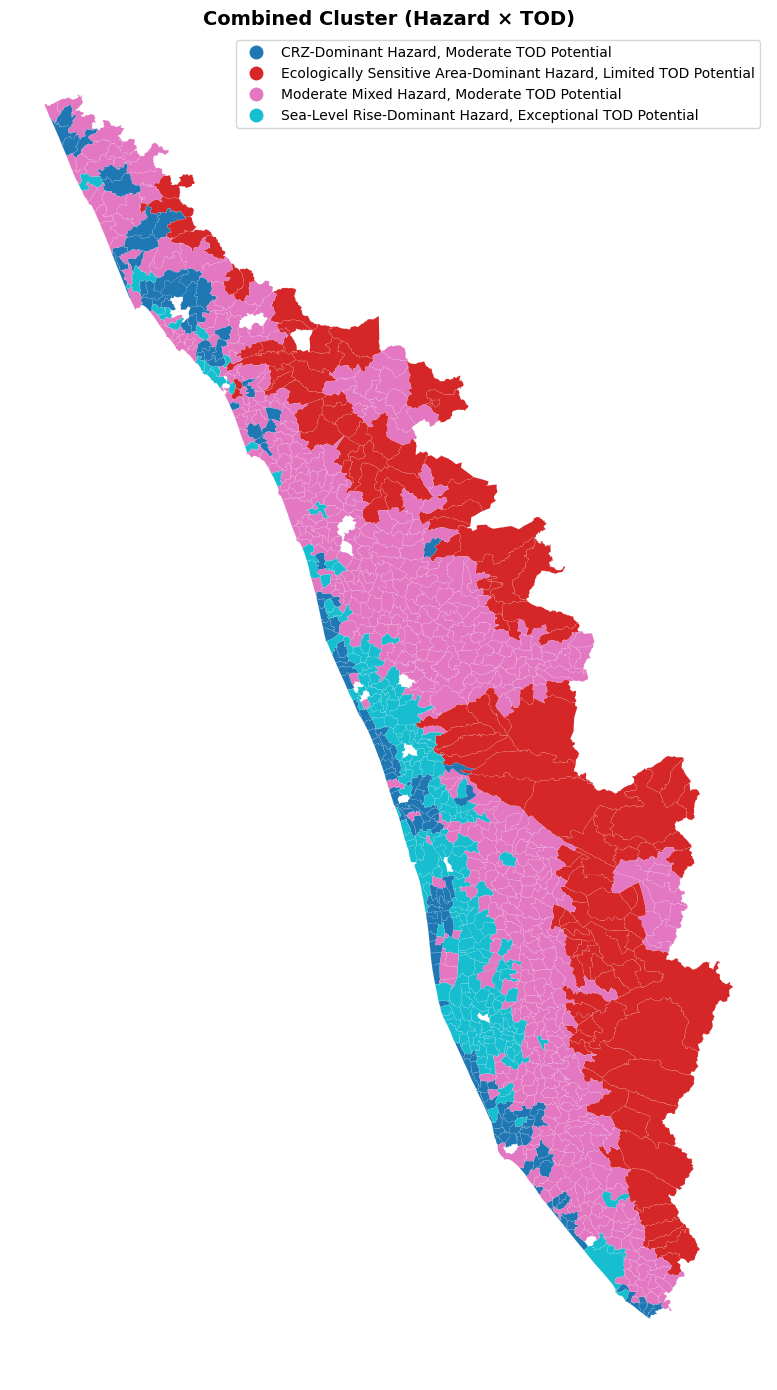

In [31]:
import matplotlib.pyplot as plt

# Remove unmatched polygons
plot_gdf = merged.dropna(subset=["Final_Cluster_Label"]).copy()

# Plot
fig, ax = plt.subplots(figsize=(8, 14))

plot_gdf.plot(
    column="Final_Cluster_Label",
    categorical=True,
    legend=True,
    linewidth=0.05,
    edgecolor="white",
    ax=ax
)

ax.set_title(
    "Combined Cluster (Hazard × TOD)",
    fontsize=14,
    fontweight="bold"
)

ax.axis("off")

plt.tight_layout()
plt.show()

In [32]:
 # ── Step 6: Export shapefile ──────────────────────────────────────────────────
# Shapefile truncates column names to 10 chars — rename first to avoid silent collisions
export_gdf = merged.rename(columns={COLUMN_TO_MAP: "ClustLabel"})

export_gdf.to_file(
    r"D:\MPLAN\research paper\final_cluster_map1.shp",
    driver="ESRI Shapefile"
)
print("Shapefile saved.")

Shapefile saved.


In [36]:
import pandas as pd
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load CSV
df = pd.read_csv(r"D:\MPLAN\research paper\datafiles\combined1.csv")

# Remove missing cluster labels
df = df.dropna(subset=["Final_Cluster_Label"])

# Variables used for clustering
features = [
    "TSI_Score",
    "SLR",
    "ESA",
    "Flood",
    "Landslide",
    "Drought",
    "CRZ"
]

X = df[features]

# Standardize (important for KMeans validation)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert text cluster labels to numbers
le = LabelEncoder()
labels = le.fit_transform(df["Final_Cluster_Label"])

# Silhouette score
score = silhouette_score(
    X_scaled,
    labels
)

print("Silhouette Score:", score)

Silhouette Score: 0.32204557403949396
